In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Minas

In [ ]:
minas = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/minas/minas.csv")
dept = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/minas/codmpio_to_dept.csv")
dept = dept.drop_duplicates()

minas = minas[['codmpio', 'ano', 'minas_civ_her', 'minas_fp_her']]
minas = minas.fillna(0)
minas = minas.merge(dept[['codmpio', 'depto']], on='codmpio', how='left')
minas.head()

,codmpio,ano,minas_civ_her,minas_fp_her,depto
0,5107.0,2021,0.0,0.0,Antioquia
1,5120.0,2021,3.0,0.0,Antioquia
2,5134.0,2021,1.0,0.0,Antioquia
3,5234.0,2021,3.0,0.0,Antioquia
4,5250.0,2021,0.0,0.0,Antioquia


In [ ]:

replace_dict = {'Bolivar': 'Bolívar', 'Boyaca': 'Boyacá', 'Caqueta': 'Caquetá', 'Cordoba': 'Córdoba',
                'Choco': 'Chocó', 'Narino': 'Nariño', 'Norte Santander': 'Norte de Santander',
                'Valle Cauca': 'Valle del Cauca', 'Guainia': 'Guainía', 'Atlantico': 'Atlántico',
                'Bogotá, D.C.': 'Bogotá D.C.', 'Bogota Dc': 'Bogotá D.C.', 'Guajira': 'La Guajira',
                'Quindio': 'Quindío', 'Archipiélago de San Andrés': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Archipielago San Andres Providencia Y Santa Catalina': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Vaupes': 'Vaupés'}
minas = minas.replace({'depto': replace_dict})
print(minas['depto'].unique())


['Antioquia' 'Bolívar' 'Boyacá' 'Caquetá' 'Cauca' 'Córdoba' 'Chocó' 'Meta'
 'Nariño' 'Norte de Santander' 'Valle del Cauca' 'Arauca' 'Putumayo'
 'Guainía' 'Guaviare' 'Atlántico' 'Bogotá D.C.' 'Caldas' 'Cesar'
 'Cundinamarca' nan 'Huila' 'La Guajira' 'Magdalena' 'Quindío' 'Risaralda'
 'Santander' 'Sucre' 'Tolima' 'Casanare'
 'Archipiélago de San Andrés, Providencia y Santa Catalina' 'Amazonas'
 'Vaupés' 'Vichada']


In [ ]:
minas['depto'] = minas['depto'].astype(str)
minas = minas.dropna()
print(sorted(minas['depto'].unique()))

minas = minas.drop('codmpio', axis=1)
minas = minas.rename(columns={'ano': 'Year', 'depto': 'Department'})
minas = minas.groupby(['Year', 'Department'], as_index=False).sum()
minas = minas[(minas['Year'] >= 2012) & (minas['Year'] <= 2022)]
minas = minas.sort_values(by=['Department', 'Year']).reset_index(drop=True)
minas.head()

['Amazonas', 'Antioquia', 'Arauca', 'Archipiélago de San Andrés, Providencia y Santa Catalina', 'Atlántico', 'Bogotá D.C.', 'Bolívar', 'Boyacá', 'Caldas', 'Caquetá', 'Casanare', 'Cauca', 'Cesar', 'Chocó', 'Cundinamarca', 'Córdoba', 'Guainía', 'Guaviare', 'Huila', 'La Guajira', 'Magdalena', 'Meta', 'Nariño', 'Norte de Santander', 'Putumayo', 'Quindío', 'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle del Cauca', 'Vaupés', 'Vichada', 'nan']


,Year,Department,minas_civ_her,minas_fp_her
0,2012,Amazonas,0.0,0.0
1,2013,Amazonas,0.0,0.0
2,2014,Amazonas,1.0,1.0
3,2015,Amazonas,0.0,0.0
4,2016,Amazonas,0.0,0.0


In [ ]:
minas.tail()

,Year,Department,minas_civ_her,minas_fp_her
335,2017,nan,0.0,0.0
336,2018,nan,0.0,0.0
337,2019,nan,0.0,0.0
338,2020,nan,0.0,0.0
339,2021,nan,0.0,0.0


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/data_11_12.csv")
data.tail()

,Department,Date,Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30)
132556,Sucre,2022-12-30,0.0,0.5610,0.734,0.998,89.7,1.11,7.608,9.370,74.81,1.201295,2.0,0.117647,201,0.04,0.0004
132557,Tolima,2022-12-30,0.0,0.6870,0.737,1.012,83.9,1.55,7.727,9.454,73.99,1.201295,1.0,0.058824,361,0.04,0.0004
132558,Valle del Cauca,2022-12-30,0.0,0.8990,0.782,0.989,98.0,6.07,9.620,9.808,74.54,1.201295,0.0,0.000000,2211,0.04,0.0004
132559,Vaupés,2022-12-30,0.0,0.0484,0.631,0.924,26.4,73.80,6.915,8.227,68.10,1.201295,0.0,0.000000,5,0.04,0.0004
132560,Vichada,2022-12-30,0.0,0.9990,0.745,0.995,97.5,3.07,8.657,9.539,74.15,1.201295,0.0,0.000000,18,0.04,0.0004


In [ ]:
def process(data, indicator_new_name, indicator, indicator_2_new_name, indicator_2):
  data = data.sort_values(by=['Year', 'Department'], ignore_index=True)

#@CITATION: CODE ADAPTED FROM CHAT GPT
  #Now match format - by day not year - for training df
  expanded_rows = []
  for index, row in data.iterrows():
    # Create a date range for each year
    date_range = pd.date_range(start=f"{row['Year']}-01-01", end=f"{row['Year']}-12-31")

    # Create a new DataFrame for the current department and year
    temp_df = pd.DataFrame({
        'Department': row['Department'],
        'Date': date_range,
        indicator_new_name: row[indicator],
        indicator_2_new_name: row[indicator_2]
    })

    # Append to the list
    expanded_rows.append(temp_df)

  # Concatenate all the temporary DataFrames into a single DataFrame
  data = pd.concat(expanded_rows, ignore_index=True)

  data['Date'] = pd.to_datetime(data['Date'])
  data['month_year'] = data['Date'].dt.to_period('M')
  columns_to_aggregate = [indicator_new_name, indicator_2_new_name]
  month_data = (
    data.groupby(['month_year', 'Department'])
        .agg({col: 'first' for col in columns_to_aggregate})
        .reset_index()
)
  start_date = pd.to_datetime('2012-01')
  month_data['month_number'] = (month_data['month_year'].dt.year - start_date.year) * 12 + (month_data['month_year'].dt.month - start_date.month)
  selected_col = ['month_number', 'Department', indicator_new_name, indicator_2_new_name]
  month_data = month_data[selected_col]


  return month_data

minas_processed = process(minas, 'Civilians Hurt by Mines', 'minas_civ_her', 'Public Personnel Hurt by Mines', 'minas_fp_her')
minas_processed.head()

#Major issue - only to 2021

,month_number,Department,Civilians Hurt by Mines,Public Personnel Hurt by Mines
0,0,Amazonas,0.0,0.0
1,0,Antioquia,39.0,45.0
2,0,Arauca,7.0,14.0
3,0,"Archipiélago de San Andrés, Providencia y Sant...",0.0,0.0
4,0,Atlántico,0.0,0.0


###Buen gobierno extracted

In [ ]:
buen_gobierno = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Buen_gobierno_extracted.csv")
dept = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/minas/codmpio_to_dept.csv")
dept = dept.drop_duplicates()
buen_gobierno = buen_gobierno[(buen_gobierno['ano'] >= 2012) & (buen_gobierno['ano'] <= 2022)]
buen_gobierno.drop(columns=['deficit', 'DF_desemp_fisc',	'DI_eficacia',	'DI_eficiencia',	'DI_capadmin',	'DI_desemp_int'], inplace=True)
buen_gobierno.head()

buen_gobierno = buen_gobierno.fillna(0)
buen_gobierno = buen_gobierno.merge(dept[['codmpio', 'depto']], on='codmpio', how='left')

replace_dict = {'Bolivar': 'Bolívar', 'Boyaca': 'Boyacá', 'Caqueta': 'Caquetá', 'Cordoba': 'Córdoba',
                'Choco': 'Chocó', 'Narino': 'Nariño', 'Norte Santander': 'Norte de Santander',
                'Valle Cauca': 'Valle del Cauca', 'Guainia': 'Guainía', 'Atlantico': 'Atlántico',
                'Bogotá, D.C.': 'Bogotá D.C.', 'Bogota Dc': 'Bogotá D.C.', 'Guajira': 'La Guajira',
                'Quindio': 'Quindío', 'Archipiélago de San Andrés': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Archipielago San Andres Providencia Y Santa Catalina': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Vaupes': 'Vaupés'}
buen_gobierno = buen_gobierno.replace({'depto': replace_dict})
print(len(buen_gobierno['depto'].unique()))
buen_gobierno['depto'] = buen_gobierno['depto'].astype(str)
buen_gobierno = buen_gobierno.dropna()

buen_gobierno = buen_gobierno.drop('codmpio', axis=1)
buen_gobierno = buen_gobierno.rename(columns={'ano': 'Year', 'depto': 'Department'})

buen_gobierno = buen_gobierno.groupby(['Department', 'Year'], as_index=False).sum()
buen_gobierno = buen_gobierno[(buen_gobierno['Year'] >= 2012) & (buen_gobierno['Year'] <= 2022)]
buen_gobierno = buen_gobierno.sort_values(by=['Department', 'Year']).reset_index(drop=True)
buen_gobierno.head()

,codmpio,ano,y_corr,y_corr_tribut,y_transf_nal,g_corr,g_func
28,5001,2012,1432734.0,1100976.0,0.0,480747.0,455969.0
29,5001,2013,1556243.0,1222234.0,33.0,458782.0,431935.0
30,5001,2014,1654233.0,1309114.0,3471.0,514442.0,470515.0
31,5001,2015,1788479.0,1435162.0,3926.0,590953.0,525198.0
32,5001,2016,1914416.0,1517342.0,4873.0,654842.0,579575.0


In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def process(data):
  data = data.sort_values(by=['Year', 'Department'], ignore_index=True)


  #Now match format - by day not year - for training df
  expanded_rows = []
  for index, row in data.iterrows():
    # Create a date range for each year
    date_range = pd.date_range(start=f"{row['Year']}-01-01", end=f"{row['Year']}-12-31")

    # Create a new DataFrame for the current department and year
    temp_df = pd.DataFrame({
        'Department': row['Department'],
        'Date': date_range,
        "Current income (millions pesos)": row["y_corr"],
        "Tax income (millions pesos)": row["y_corr_tribut"],
        "Transfers from national entities (millions of pesos)" : row["y_transf_nal"],
        "Current expensives linked to institutional performance":row["g_corr"],
        "Operating Expenses":row["g_func"],
    })

    # Append to the list
    expanded_rows.append(temp_df)

  # Concatenate all the temporary DataFrames into a single DataFrame
  data = pd.concat(expanded_rows, ignore_index=True)

  data['Date'] = pd.to_datetime(data['Date'])
  data['month_year'] = data['Date'].dt.to_period('M')
  columns_to_aggregate = ["Current income (millions pesos)", "Tax income (millions pesos)", "Transfers from national entities (millions of pesos)",
                          "Current expensives linked to institutional performance","Operating Expenses"]
  month_data = (
    data.groupby(['month_year', 'Department'])
        .agg({col: 'first' for col in columns_to_aggregate})
        .reset_index()
)
  start_date = pd.to_datetime('2012-01')
  month_data['month_number'] = (month_data['month_year'].dt.year - start_date.year) * 12 + (month_data['month_year'].dt.month - start_date.month)
  selected_col = ['month_number', 'Department'] + columns_to_aggregate
  month_data = month_data[selected_col]


  return month_data

month_data = process(buen_gobierno)
month_data = month_data.sort_values(by=['Department', 'month_number'], ignore_index=True)
month_data = month_data[month_data['Department'] != 'nan']

month_data = month_data.sort_values(by=['month_number', 'Department'], ignore_index=True)
cede_month_data = month_data
cede_month_data.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_buen_gobierno_month_data_not_std.csv", index=False)

,month_number,Department,Current income (millions pesos),Tax income (millions pesos),Transfers from national entities (millions of pesos),Current expensives linked to institutional performance,Operating Expenses
0,0,Amazonas,9749.0,6323.0,1562.0,5712.0,5367.0
1,1,Amazonas,9749.0,6323.0,1562.0,5712.0,5367.0
2,2,Amazonas,9749.0,6323.0,1562.0,5712.0,5367.0
3,3,Amazonas,9749.0,6323.0,1562.0,5712.0,5367.0
4,4,Amazonas,9749.0,6323.0,1562.0,5712.0,5367.0


###caracteristicas generales extracted

In [ ]:
cg = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/caracteristicas_generales_extracted.csv")
dept = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/minas/codmpio_to_dept.csv")
dept = dept.drop_duplicates()
cg = cg[(cg['ano'] >= 2012) & (cg['ano'] <= 2022)]


cg = cg.fillna(0)
cg = cg.merge(dept[['codmpio', 'depto']], on='codmpio', how='left')

replace_dict = {'Bolivar': 'Bolívar', 'Boyaca': 'Boyacá', 'Caqueta': 'Caquetá', 'Cordoba': 'Córdoba',
                'Choco': 'Chocó', 'Narino': 'Nariño', 'Norte Santander': 'Norte de Santander',
                'Valle Cauca': 'Valle del Cauca', 'Guainia': 'Guainía', 'Atlantico': 'Atlántico',
                'Bogotá, D.C.': 'Bogotá D.C.', 'Bogota Dc': 'Bogotá D.C.', 'Guajira': 'La Guajira',
                'Quindio': 'Quindío', 'Archipiélago de San Andrés': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Archipielago San Andres Providencia Y Santa Catalina': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Vaupes': 'Vaupés'}
cg = cg.replace({'depto': replace_dict})
print(len(cg['depto'].unique()))
cg['depto'] = cg['depto'].astype(str)
cg = cg.dropna()

cg = cg.drop('codmpio', axis=1)
cg = cg.rename(columns={'ano': 'Year', 'depto': 'Department'})

cg.sort_values(by=['Year', 'Department'], inplace=True)

In [ ]:
#area --> can just take 1 year
#disbogota --> take average
#include total population
#include include urban / rural %


In [ ]:
#cg.drop(columns=['indrural'], inplace=True)

columns_to_sum = ['areaoficialkm2', 'pobl_rur', 'pobl_urb', 'pobl_tot']
cg[columns_to_sum] = cg[columns_to_sum].replace(',', '', regex=True)
cg[columns_to_sum] = cg[columns_to_sum].astype(float)
cg.head()
cg = (
    cg.groupby(['Department', 'Year'], as_index=False)
      .agg({**{col: 'sum' for col in columns_to_sum}, 'disbogota': 'mean'})
)
cg = cg.sort_values(by=['Department', 'Year']).reset_index(drop=True)
cg.head()

area_2012 = cg[cg['Year'] == 2012][['Department', 'areaoficialkm2']].set_index('Department')
cg['areaoficialkm2'] = cg['Department'].map(area_2012['areaoficialkm2'])
cg.head(50)

latest_year = 2021
latest_data = cg[cg['Year'] == latest_year][['Department', 'Year', 'areaoficialkm2', 'disbogota', 'pobl_rur', 'pobl_urb', 'pobl_tot']].copy()

latest_data['Year'] = 2022

#@CITATION: CODE ADAPTED FROM CHAT GPT
cg = pd.concat([cg, latest_data], ignore_index=True)

cg = cg.sort_values(by=['Department', 'Year']).reset_index(drop=True)

cg.head(20)



,Department,Year,areaoficialkm2,pobl_rur,pobl_urb,pobl_tot,disbogota
0,Amazonas,2012,109665.0,46020.0,27679.0,73699.0,758.090909
1,Amazonas,2013,109665.0,46615.0,27926.0,74541.0,758.090909
2,Amazonas,2014,109665.0,47225.0,28163.0,75388.0,758.090909
3,Amazonas,2015,109665.0,47853.0,28390.0,76243.0,758.090909
4,Amazonas,2016,109665.0,48481.0,28607.0,77088.0,758.090909


In [ ]:
cg["Population Density"] = cg["pobl_tot"]/cg["areaoficialkm2"]
cg["Urban to Rural Population Ratio"] = cg["pobl_urb"]/cg["pobl_rur"]
cg["Percent Urban Population"] = cg["pobl_urb"]/cg["pobl_tot"]
cg["Percent Rural Population"] = cg["pobl_rur"]/cg["pobl_tot"]

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def process(data):
  data = data.sort_values(by=['Year', 'Department'], ignore_index=True)


  #Now match format - by day not year - for training df
  expanded_rows = []
  for index, row in data.iterrows():
    # Create a date range for each year
    date_range = pd.date_range(start=f"{row['Year']}-01-01", end=f"{row['Year']}-12-31")

    # Create a new DataFrame for the current department and year
    temp_df = pd.DataFrame({
        'Department': row['Department'],
        'Date': date_range,
        "Area km2": row["areaoficialkm2"],
        "Rural population": row["pobl_rur"],
        "Urban population" : row["pobl_urb"],
        "Total population":row["pobl_tot"],
        "Distance to Bogota":row["disbogota"],
        "Population Density": row["Population Density"],
        "Urban to Rural Population Ratio": row["Urban to Rural Population Ratio"],
        "Percent Urban Population": row["Percent Urban Population"],
        "Percent Rural Population":row["Percent Rural Population"]
    })

    # Append to the list
    expanded_rows.append(temp_df)

  # Concatenate all the temporary DataFrames into a single DataFrame
  data = pd.concat(expanded_rows, ignore_index=True)

  data['Date'] = pd.to_datetime(data['Date'])
  data['month_year'] = data['Date'].dt.to_period('M')
  columns_to_aggregate = ["Area km2","Rural population", "Urban population","Total population", "Distance to Bogota",
                          "Population Density", "Urban to Rural Population Ratio","Percent Urban Population", "Percent Rural Population" ]
  month_data = (
    data.groupby(['month_year', 'Department'])
        .agg({col: 'first' for col in columns_to_aggregate})
        .reset_index()
)
  start_date = pd.to_datetime('2012-01')
  month_data['month_number'] = (month_data['month_year'].dt.year - start_date.year) * 12 + (month_data['month_year'].dt.month - start_date.month)
  selected_col = ['month_number', 'Department'] + columns_to_aggregate
  month_data = month_data[selected_col]


  return month_data

month_data = process(cg)
month_data = month_data.sort_values(by=['Department', 'month_number'], ignore_index=True)
month_data = month_data[month_data['Department'] != 'nan']

month_data = month_data.sort_values(by=['month_number', 'Department'], ignore_index=True)
cede_month_data = month_data
cede_month_data.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_cg_month_data_not_std.csv", index=False)

In [ ]:
cede_month_data.head()

,month_number,Department,Area km2,Rural population,Urban population,Total population,Distance to Bogota,Population Density,Urban to Rural Population Ratio,Percent Urban Population,Percent Rural Population
0,0,Amazonas,109665.0,46020.0,27679.0,73699.0,758.090909,0.672038,0.601456,0.375568,0.624432
1,0,Antioquia,63612.0,1387743.0,4834074.0,6221817.0,287.592000,97.808857,3.483407,0.776955,0.223045
2,0,Arauca,23818.0,95493.0,158072.0,253565.0,417.428571,10.645940,1.655326,0.623398,0.376602
3,0,"Archipiélago de San Andrés, Providencia y Sant...",132.0,62967.0,160656.0,223623.0,1249.500000,1694.113636,2.551432,0.718423,0.281577
4,0,Atlántico,6776.0,212458.0,4534642.0,4747100.0,702.260870,700.575561,21.343710,0.955245,0.044755


###Conflicto y violencia extracted

In [ ]:
#To do
cv = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Conflicto_y_violencia_extracted.csv")
dept = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/minas/codmpio_to_dept.csv")
dept = dept.drop_duplicates()


cv = cv.fillna(0)
cv = cv.merge(dept[['codmpio', 'depto']], on='codmpio', how='left')

replace_dict = {'Bolivar': 'Bolívar', 'Boyaca': 'Boyacá', 'Caqueta': 'Caquetá', 'Cordoba': 'Córdoba',
                'Choco': 'Chocó', 'Narino': 'Nariño', 'Norte Santander': 'Norte de Santander',
                'Valle Cauca': 'Valle del Cauca', 'Guainia': 'Guainía', 'Atlantico': 'Atlántico',
                'Bogotá, D.C.': 'Bogotá D.C.', 'Bogota Dc': 'Bogotá D.C.', 'Guajira': 'La Guajira',
                'Quindio': 'Quindío', 'Archipiélago de San Andrés': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Archipielago San Andres Providencia Y Santa Catalina': 'Archipiélago de San Andrés, Providencia y Santa Catalina',
                'Vaupes': 'Vaupés'}
cv = cv.replace({'depto': replace_dict})
print(len(cv['depto'].unique()))
cv['depto'] = cv['depto'].astype(str)
cv = cv.dropna()

cv = cv.drop('codmpio', axis=1)
cv = cv.rename(columns={'ano': 'Year', 'depto': 'Department'})

cv.sort_values(by=['Year', 'Department'], inplace=True)

34


<ipython-input-55-643d5ae8a80d>:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  cv = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Conflicto_y_violencia_extracted.csv")


In [ ]:
cv.columns

Index(['Year', 'tpobc_FARC', 'tpobc_ELN', 'tpobc_AUC', 'terrorismot',
       'ataq_instpol', 'acc_subversivas', 'extorsion', 'H_coca',
       'errad_manual', 'coca', 'operacionantinarcoticos',
       'desmantelarlaboratorios', 'minas_civ_her', 'minas_civ_muer',
       'minas_fp_her', 'minas_fp_muer', 'e_aband_tierras', 'e_acto_terror',
       'e_amenaza', 'e_confina', 'e_delito_sex', 'e_desap_for', 'e_desplaza',
       'e_homic', 'e_lesiones_per', 'e_lesiones_psic', 'e_minas_anti',
       'e_perd_mue', 'e_secuest', 'e_tortura', 'Department'],
      dtype='object')

In [ ]:
#HISTORICAL DATA
#tpobc_FARC: ataques contra poblacion por FARC desde 1993-2008
#tpobc_ELN: ataques contra poblacion por ELN desde 1993-2008
#tpobc_AUC: ataques contra poblacion  por AUC desde 1993-2008
#operacionantinarcoticos: 1993-2008
#desmantelarlaboratorios: 1993-2008

#total acts of terrorism 2003-2020 ****
#total acts against police infrastructure 2003-2021
#total suversive actions 2003-2021
#total acts of extorsion 2003-2021
#hectars of coca 1999-2021
#eradd_manual hectares eradicated manually 1998-2021
#coca: dummy presence of coca cultivation 1999-2020
#'minas_civ_her', 1993-2021
#'minas_civ_muer',1993-2021
#'minas_fp_her', 1993-2021
#'minas_fp_muer',1993-2021
# 'e_aband_tierras', 1993-2021
#'e_acto_terror',1993-2021
#'e_amenaza',1993-2021
# 'e_confina',1993-2021
# 'e_delito_sex',1993-2021
# 'e_desap_for', 1993-2021
#'e_desplaza',1993-2021
#'e_homic', 1993-2021
#'e_lesiones_per',1993-2021
# 'e_lesiones_psic',1993-2021
# 'e_minas_anti',1993-2021
#'e_perd_mue',1993-2021
#'e_secuest', 1993-2021
#'e_tortura'1993-2021



In [ ]:
historical_data = cv[['Year', 'Department', 'tpobc_FARC', 'tpobc_ELN', 'tpobc_AUC','operacionantinarcoticos',
       'desmantelarlaboratorios' ]]
historical_data = historical_data.groupby(['Year', 'Department'], as_index=False).sum()
historical_data = historical_data.sort_values(by = ['Department', 'Year'])

historical_data = historical_data.groupby(['Department'], as_index=False).sum()
historical_data.drop(columns='Year', inplace=True)

historical_data = historical_data.rename(columns={
    'tpobc_FARC': 'Historical Attacks on Population By FARC (1993-2008)', 'tpobc_ELN': 'Historical Attacks on Population by ELN (1993-2008)',
    'tpobc_AUC': 'Historical Attacks on Population by AUC (1993-2008)', 'operacionantinarcoticos': "Historical Antinarcotics Operations (1993-2008)", 'desmantelarlaboratorios': "Historical Dismantling Labs (1993-2008)"
})
historical_data = historical_data[historical_data['Department'] != 'nan']
historical_data.head()

,Department,Historical Attacks on Population By FARC (1993-2008),Historical Attacks on Population by ELN (1993-2008),Historical Attacks on Population by AUC (1993-2008),Historical Antinarcotics Operations (1993-2008),Historical Dismantling Labs (1993-2008)
0,Amazonas,2.0,0.0,0.0,51.0,16.0
1,Antioquia,1050.0,731.0,418.0,1094.0,630.0
2,Arauca,197.0,144.0,60.0,127.0,133.0
3,"Archipiélago de San Andrés, Providencia y Sant...",0.0,0.0,0.0,141.0,0.0
4,Atlántico,2.0,8.0,16.0,170.0,10.0


In [ ]:
month_numbers = range(132)  # 0 to 131
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Expand the DataFrame to include all months for each department
expanded_data = historical_data.loc[historical_data.index.repeat(len(month_numbers))]

# Add the month_numbers column
expanded_data['month_numbers'] = list(month_numbers) * len(historical_data)

# Reset the index
expanded_data.reset_index(drop=True, inplace=True)
historical_data = expanded_data.sort_values(by=['month_numbers', 'Department'], ignore_index=True)
historical_data = historical_data[['month_numbers'] + [col for col in historical_data.columns if col != 'month_numbers']]
historical_data.reset_index(drop=True, inplace=True)
historical_data.head()


,month_numbers,Department,Historical Attacks on Population By FARC (1993-2008),Historical Attacks on Population by ELN (1993-2008),Historical Attacks on Population by AUC (1993-2008),Historical Antinarcotics Operations (1993-2008),Historical Dismantling Labs (1993-2008)
0,0,Amazonas,2.0,0.0,0.0,51.0,16.0
1,0,Antioquia,1050.0,731.0,418.0,1094.0,630.0
2,0,Arauca,197.0,144.0,60.0,127.0,133.0
3,0,"Archipiélago de San Andrés, Providencia y Sant...",0.0,0.0,0.0,141.0,0.0
4,0,Atlántico,2.0,8.0,16.0,170.0,10.0


In [ ]:
historical_data = historical_data.rename(columns={'month_numbers': 'month_number'})
historical_data.head()

,month_number,Department,Historical Attacks on Population By FARC (1993-2008),Historical Attacks on Population by ELN (1993-2008),Historical Attacks on Population by AUC (1993-2008),Historical Antinarcotics Operations (1993-2008),Historical Dismantling Labs (1993-2008)
0,0,Amazonas,2.0,0.0,0.0,51.0,16.0
1,0,Antioquia,1050.0,731.0,418.0,1094.0,630.0
2,0,Arauca,197.0,144.0,60.0,127.0,133.0
3,0,"Archipiélago de San Andrés, Providencia y Sant...",0.0,0.0,0.0,141.0,0.0
4,0,Atlántico,2.0,8.0,16.0,170.0,10.0


In [ ]:
historical_data.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_cv_historical_data_not_std.csv", index=False)

In [ ]:
cv = cv[['Department', 'Year',  'terrorismot',
       'ataq_instpol', 'acc_subversivas', 'extorsion', 'H_coca',
       'errad_manual', 'coca',  'minas_civ_her', 'minas_civ_muer',
       'minas_fp_her', 'minas_fp_muer', 'e_aband_tierras', 'e_acto_terror',
       'e_amenaza', 'e_confina', 'e_delito_sex', 'e_desap_for', 'e_desplaza',
       'e_homic', 'e_lesiones_per', 'e_lesiones_psic', 'e_minas_anti',
       'e_perd_mue', 'e_secuest', 'e_tortura']]
cv = cv[(cv['Year'] >= 2012) & (cv['Year'] <= 2022)]
cv.head()

,Department,Year,terrorismot,ataq_instpol,acc_subversivas,extorsion,H_coca,errad_manual,coca,minas_civ_her,...,e_delito_sex,e_desap_for,e_desplaza,e_homic,e_lesiones_per,e_lesiones_psic,e_minas_anti,e_perd_mue,e_secuest,e_tortura
44183,Amazonas,2012,0.0,0.0,0.0,1.0,0.0,0,0.0,0.0,...,0.0,0.0,86.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0
44212,Amazonas,2012,0.0,0.0,0.0,0.0,16.0,9.00,1.0,0.0,...,0.0,5.0,30.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
44241,Amazonas,2012,0.0,0.0,0.0,0.0,22.0,0,1.0,0.0,...,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44270,Amazonas,2012,0.0,0.0,0.0,0.0,1.0,0,1.0,0.0,...,1.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44299,Amazonas,2012,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

#total acts of terrorism 2003-2020 ****
#total acts against police infrastructure 2003-2021
#total suversive actions 2003-2021
#total acts of extorsion 2003-2021
#hectars of coca 1999-2021
#eradd_manual hectares eradicated manually 1998-2021
#coca: dummy presence of coca cultivation 1999-2020
#'minas_civ_her', 1993-2021
#'minas_civ_muer',1993-2021
#'minas_fp_her', 1993-2021
#'minas_fp_muer',1993-2021
# 'e_aband_tierras', 1993-2021
#'e_acto_terror',1993-2021
#'e_amenaza',1993-2021
# 'e_confina',1993-2021
# 'e_delito_sex',1993-2021
# 'e_desap_for', 1993-2021
#'e_desplaza',1993-2021
#'e_homic', 1993-2021
#'e_lesiones_per',1993-2021
# 'e_lesiones_psic',1993-2021
# 'e_minas_anti',1993-2021
#'e_perd_mue',1993-2021
#'e_secuest', 1993-2021
#'e_tortura'1993-2021

In [ ]:
#cg.drop(columns=['indrural'], inplace=True)

columns_to_sum = ['terrorismot',
       'ataq_instpol', 'acc_subversivas', 'extorsion', 'H_coca',
       'errad_manual', 'coca',  'minas_civ_her', 'minas_civ_muer',
       'minas_fp_her', 'minas_fp_muer', 'e_aband_tierras', 'e_acto_terror',
       'e_amenaza', 'e_confina', 'e_delito_sex', 'e_desap_for', 'e_desplaza',
       'e_homic', 'e_lesiones_per', 'e_lesiones_psic', 'e_minas_anti',
       'e_perd_mue', 'e_secuest', 'e_tortura']
cv[columns_to_sum] = cv[columns_to_sum].replace(',', '', regex=True)
cv[columns_to_sum] = cv[columns_to_sum].astype(float)

cv = (
    cv.groupby(['Department', 'Year'], as_index=False)
      .agg({**{col: 'sum' for col in columns_to_sum}})
)
cv = cv.sort_values(by=['Department', 'Year']).reset_index(drop=True)
cv.head()


,Department,Year,terrorismot,ataq_instpol,acc_subversivas,extorsion,H_coca,errad_manual,coca,minas_civ_her,...,e_delito_sex,e_desap_for,e_desplaza,e_homic,e_lesiones_per,e_lesiones_psic,e_minas_anti,e_perd_mue,e_secuest,e_tortura
0,Amazonas,2012,0.0,0.0,0.0,2.0,98.0,10.00,5.0,0.0,...,3.0,5.0,167.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Amazonas,2013,0.0,0.0,0.0,3.0,110.0,2.00,4.0,0.0,...,0.0,3.0,189.0,20.0,0.0,0.0,0.0,4.0,1.0,0.0
2,Amazonas,2014,2.0,0.0,2.0,3.0,173.0,5.11,3.0,1.0,...,6.0,0.0,261.0,4.0,2.0,0.0,3.0,1.0,2.0,0.0
3,Amazonas,2015,0.0,0.0,0.0,3.0,112.0,10.14,3.0,0.0,...,0.0,3.0,197.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0
4,Amazonas,2016,0.0,0.0,0.0,4.0,167.0,0.00,3.0,0.0,...,0.0,5.0,109.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0


In [ ]:
cv['coca'] = (cv['coca'] >= 1).astype(float)

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Step 1: Filter the 2021 data
latest_year = 2021
latest_data = cv[cv['Year'] == latest_year][['Department', 'Year', 'terrorismot',
       'ataq_instpol', 'acc_subversivas', 'extorsion', 'H_coca',
       'errad_manual', 'coca',  'minas_civ_her', 'minas_civ_muer',
       'minas_fp_her', 'minas_fp_muer', 'e_aband_tierras', 'e_acto_terror',
       'e_amenaza', 'e_confina', 'e_delito_sex', 'e_desap_for', 'e_desplaza',
       'e_homic', 'e_lesiones_per', 'e_lesiones_psic', 'e_minas_anti',
       'e_perd_mue', 'e_secuest', 'e_tortura']].copy()

# Step 2: Update the Year to 2022 and add empty columns for population
latest_data['Year'] = 2022


# Step 3: Append the new rows to the original DataFrame
cv = pd.concat([cv, latest_data], ignore_index=True)

# Step 4: Sort by Department and Year
cv = cv.sort_values(by=['Department', 'Year']).reset_index(drop=True)

cv.head(20)

,Department,Year,terrorismot,ataq_instpol,acc_subversivas,extorsion,H_coca,errad_manual,coca,minas_civ_her,...,e_delito_sex,e_desap_for,e_desplaza,e_homic,e_lesiones_per,e_lesiones_psic,e_minas_anti,e_perd_mue,e_secuest,e_tortura
0,Amazonas,2012,0.0,0.0,0.0,2.0,98.0,10.00,1.0,0.0,...,3.0,5.0,167.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Amazonas,2013,0.0,0.0,0.0,3.0,110.0,2.00,1.0,0.0,...,0.0,3.0,189.0,20.0,0.0,0.0,0.0,4.0,1.0,0.0
2,Amazonas,2014,2.0,0.0,2.0,3.0,173.0,5.11,1.0,1.0,...,6.0,0.0,261.0,4.0,2.0,0.0,3.0,1.0,2.0,0.0
3,Amazonas,2015,0.0,0.0,0.0,3.0,112.0,10.14,1.0,0.0,...,0.0,3.0,197.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0
4,Amazonas,2016,0.0,0.0,0.0,4.0,167.0,0.00,1.0,0.0,...,0.0,5.0,109.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
5,Amazonas,2017,0.0,0.0,0.0,4.0,165.0,19.98,1.0,0.0,...,1.0,0.0,105.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
6,Amazonas,2018,0.0,0.0,0.0,2.0,121.0,71.30,1.0,0.0,...,1.0,0.0,98.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
7,Amazonas,2019,0.0,0.0,0.0,6.0,125.0,0.69,1.0,0.0,...,3.0,0.0,67.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0
8,Amazonas,2020,0.0,0.0,0.0,5.0,61.0,3.69,1.0,0.0,...,5.0,0.0,53.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
9,Amazonas,2021,0.0,0.0,0.0,3.0,73.0,0.00,1.0,0.0,...,0.0,7.0,102.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
cv.columns

Index(['Department', 'Year', 'terrorismot', 'ataq_instpol', 'acc_subversivas',
       'extorsion', 'H_coca', 'errad_manual', 'coca', 'minas_civ_her',
       'minas_civ_muer', 'minas_fp_her', 'minas_fp_muer', 'e_aband_tierras',
       'e_acto_terror', 'e_amenaza', 'e_confina', 'e_delito_sex',
       'e_desap_for', 'e_desplaza', 'e_homic', 'e_lesiones_per',
       'e_lesiones_psic', 'e_minas_anti', 'e_perd_mue', 'e_secuest',
       'e_tortura'],
      dtype='object')

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT

def process(data):
  data = data.sort_values(by=['Year', 'Department'], ignore_index=True)


  #Now match format - by day not year - for training df
  expanded_rows = []
  for index, row in data.iterrows():
    # Create a date range for each year
    date_range = pd.date_range(start=f"{row['Year']}-01-01", end=f"{row['Year']}-12-31")

    # Create a new DataFrame for the current department and year
    temp_df = pd.DataFrame({
        'Department': row['Department'],
        'Date': date_range,
        "Total acts of terrorism": row["terrorismot"],
        "Total acts against police": row["ataq_instpol"],
        "Total subversive actions" : row["acc_subversivas"],
        "Total acts of extorsion":row["extorsion"],
        "Hectares of coca":row["H_coca"],
        "Hectores of coca erdaicted manually ": row["errad_manual"],
        "Presence of coca cultivation (dummy)": row["coca"],
        "Civilians hurt by mines": row["minas_civ_her"],
        "Civilians killed by mines":row["minas_civ_muer"],
        "Public force members hurt by mines": row["minas_fp_her"],
        "Public force members killed by mines":row["minas_fp_muer"],
        "Events of Abandoned property": row["e_aband_tierras"],
        "Events of Acts of Terrorism": row["e_acto_terror"],
        "Events of Threats": row["e_amenaza"],
        "Events of Confinement": row["e_confina"],
        "Events of Sexual Crimes": row["e_delito_sex"],
        "Events of Forced Disappearances": row["e_desap_for"],
        "Events of Displacement": row["e_desplaza"],
        "Events of Homicide": row["e_homic"],
        "Events of Personal Physical Injuries": row["e_lesiones_per"],
        "Events of Personal Pyschological Injuries": row["e_lesiones_psic"],
        "Events of Mine Explosions": row["e_minas_anti"],
        "Events of Loss of Estate": row["e_perd_mue"],
        "Events of Kiddnapping": row["e_secuest"],
        "Events of Torture": row["e_tortura"]



    })

    # Append to the list
    expanded_rows.append(temp_df)

  # Concatenate all the temporary DataFrames into a single DataFrame
  data = pd.concat(expanded_rows, ignore_index=True)

  data['Date'] = pd.to_datetime(data['Date'])
  data['month_year'] = data['Date'].dt.to_period('M')
  columns_to_aggregate = ["Total acts of terrorism",
        "Total acts against police",
        "Total subversive actions",
        "Total acts of extorsion",
        "Hectares of coca",
        "Hectores of coca erdaicted manually ",
        "Presence of coca cultivation (dummy)",
        "Civilians hurt by mines",
        "Civilians killed by mines",
        "Public force members hurt by mines",
        "Public force members killed by mines",
        "Events of Abandoned property",
        "Events of Acts of Terrorism",
        "Events of Threats",
        "Events of Confinement",
        "Events of Sexual Crimes",
        "Events of Forced Disappearances",
        "Events of Displacement",
        "Events of Homicide",
        "Events of Personal Physical Injuries",
        "Events of Personal Pyschological Injuries",
        "Events of Mine Explosions",
        "Events of Loss of Estate",
        "Events of Kiddnapping",
        "Events of Torture" ]
  month_data = (
    data.groupby(['month_year', 'Department'])
        .agg({col: 'first' for col in columns_to_aggregate})
        .reset_index()
)
  start_date = pd.to_datetime('2012-01')
  month_data['month_number'] = (month_data['month_year'].dt.year - start_date.year) * 12 + (month_data['month_year'].dt.month - start_date.month)
  selected_col = ['month_number', 'Department'] + columns_to_aggregate
  month_data = month_data[selected_col]


  return month_data

month_data = process(cv)
month_data = month_data.sort_values(by=['Department', 'month_number'], ignore_index=True)
month_data.head(20)


,month_number,Department,Total acts of terrorism,Total acts against police,Total subversive actions,Total acts of extorsion,Hectares of coca,Hectores of coca erdaicted manually,Presence of coca cultivation (dummy),Civilians hurt by mines,...,Events of Sexual Crimes,Events of Forced Disappearances,Events of Displacement,Events of Homicide,Events of Personal Physical Injuries,Events of Personal Pyschological Injuries,Events of Mine Explosions,Events of Loss of Estate,Events of Kiddnapping,Events of Torture
0,0,Amazonas,0.0,0.0,0.0,2.0,98.0,10.00,1.0,0.0,...,3.0,5.0,167.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,Antioquia,94.0,2.0,21.0,361.0,2725.0,2406.48,1.0,39.0,...,113.0,178.0,49110.0,3022.0,126.0,3.0,149.0,441.0,127.0,26.0
2,0,Arauca,81.0,11.0,20.0,63.0,82.0,2.50,1.0,7.0,...,14.0,47.0,3815.0,489.0,32.0,1.0,34.0,115.0,59.0,9.0
3,0,"Archipiélago de San Andrés, Providencia y Sant...",0.0,0.0,0.0,15.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,Atlántico,2.0,0.0,0.0,126.0,0.0,0.00,0.0,0.0,...,20.0,0.0,1560.0,120.0,2.0,0.0,0.0,24.0,2.0,0.0
5,0,Bogotá D.C.,48.0,0.0,0.0,478.0,0.0,0.00,0.0,0.0,...,16.0,4.0,1464.0,104.0,10.0,0.0,0.0,96.0,6.0,10.0
6,0,Bolívar,12.0,0.0,0.0,218.0,3936.0,367.44,1.0,4.0,...,50.0,18.0,12716.0,662.0,12.0,0.0,6.0,228.0,32.0,10.0
7,0,Boyacá,10.0,0.0,0.0,160.0,20.0,680.82,1.0,0.0,...,10.0,16.0,1452.0,108.0,0.0,0.0,2.0,16.0,20.0,2.0
8,0,Caldas,0.0,0.0,0.0,39.0,16.0,47.80,1.0,0.0,...,6.0,10.0,1366.0,130.0,1.0,0.0,0.0,12.0,8.0,1.0
9,0,Caquetá,52.0,0.0,6.0,56.0,7388.0,751.38,1.0,8.0,...,64.0,138.0,28540.0,1348.0,66.0,8.0,84.0,1664.0,138.0,54.0


In [ ]:
month_data.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_cv_data_not_std.csv", index=False)

###Combining with other data

In [ ]:
bg = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_buen_gobierno_month_data_not_std.csv")
cg = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_cg_month_data_not_std.csv")
historical_data = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_cv_historical_data_not_std.csv")
cv = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/cede_cv_data_not_std.csv")

In [ ]:
cede_month_data = pd.merge(bg, cg, on=['month_number', 'Department'], how='inner')
cede_month_data = pd.merge(cede_month_data, historical_data, on=['month_number', 'Department'], how='inner')
cede_month_data = pd.merge(cede_month_data, cv, on=['month_number', 'Department'], how='inner')
cede_month_data.head()

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/11_12 Final/data_11_12.csv")

In [ ]:
data.columns

Index(['Department', 'Date', 'Quantity Seized (kg)',
       'Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)'],
      dtype='object')

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data['month_year'] = data['Date'].dt.to_period('M')
columns_to_aggregate = ['Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)',]
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Group by month_year and Department, summing the quantity seized and taking the first for other columns
month_data = (data
                  .groupby(['month_year', 'Department'])
                  .agg({'Quantity Seized (kg)': 'sum',
                        **{col: 'first' for col in columns_to_aggregate}})
                  .reset_index())
month_data.rename(columns={'Quantity Seized (kg)': 'Monthly Quantity Seized (kg)'}, inplace=True)
month_data['Log Monthly Quantity Seized (kg)'] = np.log1p(month_data['Monthly Quantity Seized (kg)'])
month_data = month_data.sort_values(by=['Department', 'month_year'])
month_data['month_year'] = month_data['month_year'].dt.to_timestamp()

# Define the starting date (January 2012 as month 0)
start_date = pd.to_datetime('2012-01')

# Calculate month number by finding the difference in months
month_data['month_number'] = (month_data['month_year'].dt.year - start_date.year) * 12 + (month_data['month_year'].dt.month - start_date.month)
month_data = month_data.sort_values(by=['Department', 'month_number']).reset_index(drop=True)
cols_to_move = ['month_number', 'Department', 'Monthly Quantity Seized (kg)', 'Log Monthly Quantity Seized (kg)']
cols = cols_to_move + [col for col in month_data.columns if col not in cols_to_move]
month_data = month_data[cols]

month_data.drop(columns=['month_year'], inplace=True)

In [ ]:
border_depts = ['Nariño', 'Putumayo', 'Amazonas', 'Vaupés', 'Guainia', 'Vichada', 'Arauca', 'Norte de Santander', 'Cesar', 'La Guajira', 'Choco' ]
ocean_depts = ['Nariño', 'Cauca', 'Valle del Cauca', 'Chocó', 'Antioquia', 'Córdoba', 'Sucre', 'Bolívar', 'Atlántico', 'Magdalena', 'La Guajira']
month_data['Border_Department'] = month_data['Department'].apply(lambda x: 1 if x in border_depts else 0)
month_data['Ocean_department'] = month_data['Department'].apply(lambda x: 1 if x in ocean_depts else 0)

month_data.sort_values(by=['Department', 'month_number'], inplace=True)

In [ ]:
month_data.tail()

,month_number,Department,Monthly Quantity Seized (kg),Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30),Border_Department,Ocean_department
4351,127,Vichada,810.000,6.698268,0.999,0.745,0.995,97.5,3.07,8.657,9.539,74.15,48.823199,0.0,0.0,18,0.06,0.0021,1,0
4352,128,Vichada,0.000,0.000000,0.999,0.745,0.995,97.5,3.07,8.657,9.539,74.15,53.520808,0.0,0.0,18,0.07,0.0460,1,0
4353,129,Vichada,537.870,6.289474,0.999,0.745,0.995,97.5,3.07,8.657,9.539,74.15,14.476301,0.0,0.0,18,0.06,0.0092,1,0
4354,130,Vichada,59.530,4.103139,0.999,0.745,0.995,97.5,3.07,8.657,9.539,74.15,76.000373,0.0,0.0,18,0.03,0.0002,1,0
4355,131,Vichada,83.855,4.440944,0.999,0.745,0.995,97.5,3.07,8.657,9.539,74.15,222.857699,0.0,0.0,18,0.11,0.0108,1,0


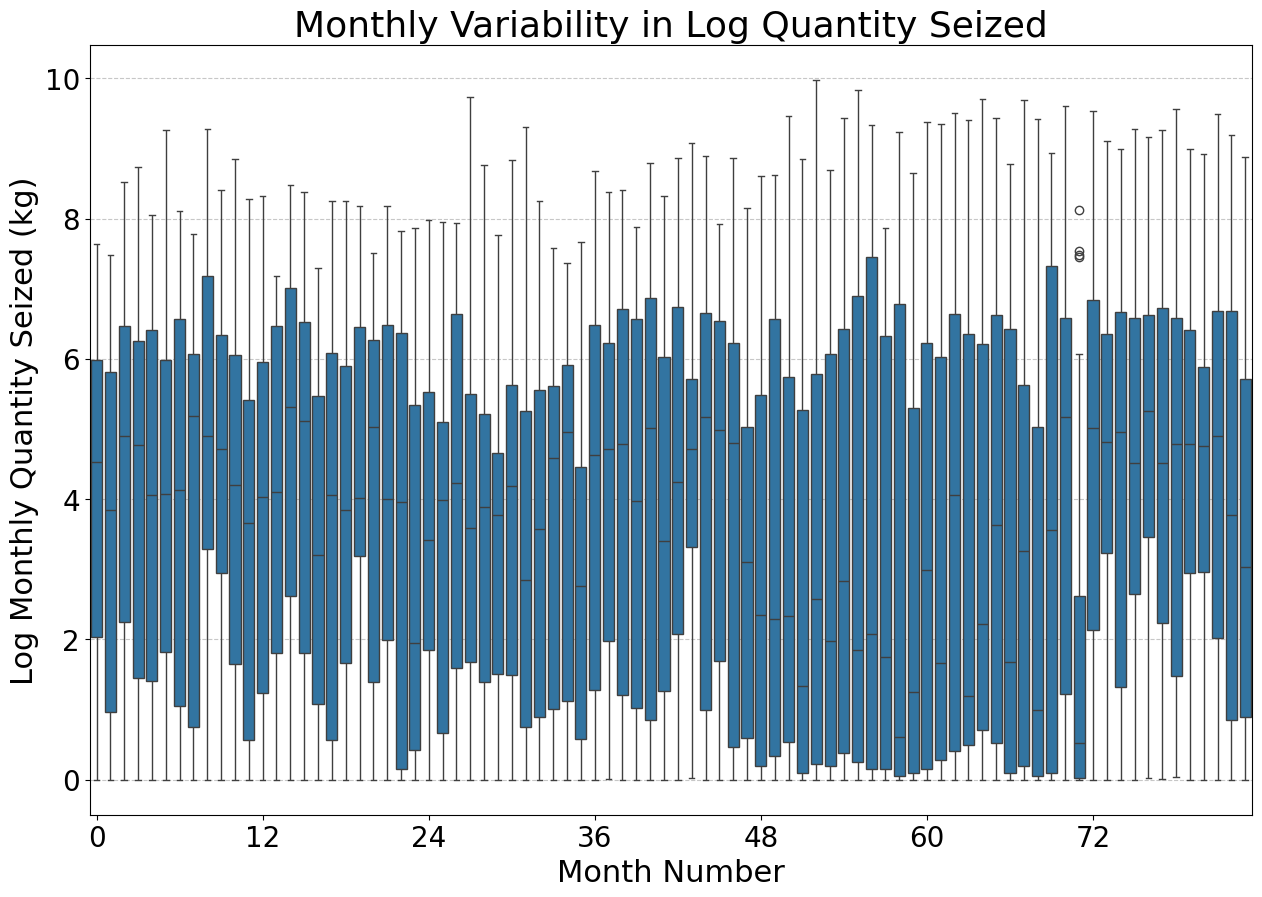

In [ ]:
train_month_data = month_data[month_data['month_number'] < 84]
train_month_data.tail()
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Create the plot
plt.figure(figsize=(15, 10))
sns.boxplot(x='month_number', y='Log Monthly Quantity Seized (kg)', data=train_month_data)

# Customize x-ticks to show only every 12 months and change the font
ticks = range(0, train_month_data['month_number'].max() + 1, 12)  # Every 12 months
plt.xticks(ticks, labels=ticks, fontsize=20, fontfamily='sans-serif')  # Adjust font family and size
plt.yticks(fontsize=20, fontfamily='sans-serif')
# Set other font customizations
plt.title("Monthly Variability in Log Quantity Seized", fontsize=26, fontfamily='sans-serif')
plt.xlabel("Month Number", fontsize=22, fontfamily='sans-serif')
plt.ylabel("Log Monthly Quantity Seized (kg)", fontsize=22, fontfamily='sans-serif')

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
cede_month_data.sort_values(by=['Department', 'month_number'], inplace=True)
cede_month_data.tail()

,month_number,Department,Current income (millions pesos),Tax income (millions pesos),Transfers from national entities (millions of pesos),Current expensives linked to institutional performance,Operating Expenses,Area km2,Rural population,Urban population,...,Events of Sexual Crimes,Events of Forced Disappearances,Events of Displacement,Events of Homicide,Events of Personal Physical Injuries,Events of Personal Pyschological Injuries,Events of Mine Explosions,Events of Loss of Estate,Events of Kiddnapping,Events of Torture
4223,127,Vichada,36820.0,23082.0,11794.0,18180.0,17767.0,100242.0,86555.0,28002.0,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4256,128,Vichada,36820.0,23082.0,11794.0,18180.0,17767.0,100242.0,86555.0,28002.0,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4289,129,Vichada,36820.0,23082.0,11794.0,18180.0,17767.0,100242.0,86555.0,28002.0,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4322,130,Vichada,36820.0,23082.0,11794.0,18180.0,17767.0,100242.0,86555.0,28002.0,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4355,131,Vichada,36820.0,23082.0,11794.0,18180.0,17767.0,100242.0,86555.0,28002.0,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0


In [ ]:
combined = pd.merge(month_data, cede_month_data, on=['month_number', 'Department'], how='inner')
combined.tail()

,month_number,Department,Monthly Quantity Seized (kg),Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,...,Events of Sexual Crimes,Events of Forced Disappearances,Events of Displacement,Events of Homicide,Events of Personal Physical Injuries,Events of Personal Pyschological Injuries,Events of Mine Explosions,Events of Loss of Estate,Events of Kiddnapping,Events of Torture
4351,127,Vichada,810.000,6.698268,0.999,0.745,0.995,97.5,3.07,8.657,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4352,128,Vichada,0.000,0.000000,0.999,0.745,0.995,97.5,3.07,8.657,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4353,129,Vichada,537.870,6.289474,0.999,0.745,0.995,97.5,3.07,8.657,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4354,130,Vichada,59.530,4.103139,0.999,0.745,0.995,97.5,3.07,8.657,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0
4355,131,Vichada,83.855,4.440944,0.999,0.745,0.995,97.5,3.07,8.657,...,1.0,0.0,123.0,4.0,0.0,0.0,0.0,6.0,1.0,0.0


In [ ]:
train_encoded = combined[combined['month_number'] < 82]
val_encoded = combined[(combined['month_number'] >= 82) & (combined['month_number'] < 107)]
test_encoded = combined[combined['month_number'] >= 107].reset_index(drop=True)
final_train = pd.concat([train_encoded, val_encoded], axis=0).reset_index(drop=True)

train_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/train_encoded_not_std_no_engineering.csv", index=False)
val_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/val_encoded_not_std_no_engineering.csv", index=False)
test_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/test_encoded_not_std_no_engineering.csv", index=False)
final_train.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/final_train_not_std_no_engineering.csv", index=False)

###Lag feature engineering

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
#sort by department then year instead of year then department
combined_df = combined.sort_values(by=['Department', 'month_number'])
combined_df = combined.drop(columns=['Monthly Quantity Seized (kg)'])


#LAGS
combined_df['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(1)
combined_df['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(2)
combined_df['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(3)
combined_df['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(4)
combined_df['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(5)
combined_df['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(6)


#ROLLING AVERAGES
combined_df['Rolling_3M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').mean())
combined_df['Rolling_6M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').mean())


# ROLLING STD DEV
combined_df['Rolling_3M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').std())
combined_df['Rolling_6M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').std())

#ROLLING MIN
combined_df['Rolling_3M_Min_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(3, closed='left').min())
combined_df['Rolling_6M_Min_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(6, closed='left').min())

#ROLLING MAX
combined_df['Rolling_3M_Max_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(3, closed='left').max())
combined_df['Rolling_6M_Max_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(6, closed='left').max())
#ROLLING RANGE
combined_df['Rolling_3M_Range_Log_Monthly_Quantity'] = (
    combined_df['Rolling_3M_Max_Log_Monthly_Quantity'] - combined_df['Rolling_3M_Min_Log_Monthly_Quantity'])
combined_df['Rolling_6M_Range_Log_Monthly_Quantity'] = (
    combined_df['Rolling_6M_Max_Log_Monthly_Quantity'] - combined_df['Rolling_3M_Min_Log_Monthly_Quantity'])

#EMA
combined_df['EMA_3M_Log_Monthly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Monthly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
)
combined_df['EMA_6M_Log_Monthly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Monthly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=6, adjust=False).mean())
)


#MOMENTUM
combined_df['Momentum_3_6'] = (
    combined_df['Rolling_6M_Log_Monthly_Quantity'].shift(1) - combined_df['Rolling_3M_Log_Monthly_Quantity'].shift(1) )



#Cumulative sum per year
combined_df['Year'] = 2012 + (combined_df['month_number'] // 12)
combined_df['Cumulative_Log_Monthly_Quantity_Seized_Per_Year'] = (
    combined_df.groupby(['Department', 'Year'])['Log Monthly Quantity Seized (kg)']
    .cumsum()
    .shift(1)
)
combined_df.drop(columns=['Year'], inplace=True)

#Cumulative rolling sum




#season
combined_df['month'] = combined_df['month_number'] % 12
def get_season(month):
    if month in [11, 0, 1]:      # December, January, February
        return 'Winter'
    elif month in [2, 3, 4]:     # March, April, May
        return 'Spring'
    elif month in [5, 6, 7]:     # June, July, August
        return 'Summer'
    elif month in [8, 9, 10]:    # September, October, November
        return 'Fall'
combined_df['season'] = combined_df['month'].apply(get_season)
combined_df.drop(columns=['month'], inplace=True)
combined_df = pd.get_dummies(combined_df, columns=['season'], drop_first=True)
dept_columns = [col for col in combined_df.columns if col.startswith('season_')]
for col in dept_columns:
  combined_df[col] = combined_df[col].apply(lambda x: 1 if x == True else 0)




# drop Nan
combined_lagged = combined_df.dropna(subset=['Lagged_Log_Monthly_Quantity_Seized_1',
       'Lagged_Log_Monthly_Quantity_Seized_2',
       'Lagged_Log_Monthly_Quantity_Seized_3',
       'Lagged_Log_Monthly_Quantity_Seized_4',
       'Lagged_Log_Monthly_Quantity_Seized_5',
       'Lagged_Log_Monthly_Quantity_Seized_6',
       'Rolling_3M_Log_Monthly_Quantity','Rolling_6M_Log_Monthly_Quantity',
       'Rolling_3M_Std_Log_Monthly_Quantity', 'Rolling_6M_Std_Log_Monthly_Quantity',
       'Rolling_3M_Min_Log_Monthly_Quantity', 'Rolling_6M_Min_Log_Monthly_Quantity',
       'Rolling_3M_Max_Log_Monthly_Quantity', 'Rolling_6M_Max_Log_Monthly_Quantity',
       'Rolling_3M_Range_Log_Monthly_Quantity', 'Rolling_6M_Range_Log_Monthly_Quantity',
        'EMA_3M_Log_Monthly_Quantity', 'EMA_6M_Log_Monthly_Quantity',
       'Momentum_3_6',
       'Cumulative_Log_Monthly_Quantity_Seized_Per_Year',
        'season_Spring', 'season_Summer','season_Winter'
        ]).reset_index(drop=True)


#Growth rates
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_4'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_5'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6'].replace(0, 1e-10)

combined_lagged['Growth_Rate_Lag_1_2'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']

combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_2_3'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']
combined_lagged['Growth_Rate_Lag_1_3'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']




#one hot encode departments
combined_lagged_encoded = pd.get_dummies(combined_lagged, columns=['Department'], drop_first = True) # not drop firsting!
dept_columns = [col for col in combined_lagged_encoded.columns if col.startswith('Department_')]
for col in dept_columns:
  combined_lagged_encoded[col] = combined_lagged_encoded[col].apply(lambda x: 1 if x == True else 0)


combined_lagged_encoded.head()



,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,7,2.484907,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
1,8,1.181727,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
2,9,0.000000,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
3,10,0.000000,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
4,11,0.000000,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#split train val test (60, 20, 20)
train_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] < 82]
val_encoded = combined_lagged_encoded[(combined_lagged_encoded['month_number'] >= 82) & (combined_lagged_encoded['month_number'] < 107)]
test_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] >= 107].reset_index(drop=True)
final_train = pd.concat([train_encoded, val_encoded], axis=0).reset_index(drop=True)
print("training split: ", len(train_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("val split: ", len(val_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("test split: ", len(test_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
train_encoded.head()



training split:  0.6
val split:  0.2
test split:  0.2


,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,7,2.484907,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
1,8,1.181727,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
2,9,0.000000,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
3,10,0.000000,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0
4,11,0.000000,0.376,0.676,0.95,58.3,24.4,7.017,8.734,73.49,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/train_encoded_not_std.csv", index=False)
val_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/val_encoded_not_std.csv", index=False)
test_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/test_encoded_not_std.csv", index=False)
final_train.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/Not standardized/final_train_not_std.csv", index=False)

In [ ]:
deptfeatures = ['Log Monthly Quantity Seized (kg)', 'month_number',
                             'Border_Department',
       'Ocean_department', 'Department_Antioquia', 'Department_Arauca',
       'Department_Archipiélago de San Andrés, Providencia y Santa Catalina',
       'Department_Atlántico', 'Department_Bogotá D.C.', 'Department_Bolívar',
       'Department_Boyacá', 'Department_Caldas', 'Department_Caquetá',
       'Department_Casanare', 'Department_Cauca', 'Department_Cesar',
       'Department_Chocó', 'Department_Cundinamarca', 'Department_Córdoba',
       'Department_Guainía', 'Department_Guaviare', 'Department_Huila',
       'Department_La Guajira', 'Department_Magdalena', 'Department_Meta',
       'Department_Nariño', 'Department_Norte de Santander',
       'Department_Putumayo', 'Department_Quindío', 'Department_Risaralda',
       'Department_Santander', 'Department_Sucre', 'Department_Tolima',
       'Department_Valle del Cauca', 'Department_Vaupés',
       'Department_Vichada']
socioeconomic_features = ['Percent Population in Urban Areas', 'HDI', 'GDI', 'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births', 'Mean Years Schooling', 'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy', 'Population Density_x', 'Number of Corruption Cases', 'Percent of Total Corruption Cases for That Year', 'Number of Homicides that Year', 'Gini Coefficient', '% Poorest Household (IWI under 30)']
cede_features = ['Current income (millions pesos)', 'Tax income (millions pesos)', 'Transfers from national entities (millions of pesos)', 'Current expensives linked to institutional performance', 'Operating Expenses', 'Area km2', 'Rural population', 'Urban population', 'Total population', 'Distance to Bogota', 'Population Density_y', 'Urban to Rural Population Ratio', 'Percent Urban Population', 'Percent Rural Population', 'Historical Attacks on Population By FARC (1993-2008)', 'Historical Attacks on Population by ELN (1993-2008)', 'Historical Attacks on Population by AUC (1993-2008)', 'Historical Antinarcotics Operations (1993-2008)', 'Historical Dismantling Labs (1993-2008)', 'Total acts of terrorism', 'Total acts against police', 'Total subversive actions', 'Total acts of extorsion', 'Hectares of coca', 'Hectores of coca erdaicted manually ', 'Presence of coca cultivation (dummy)', 'Civilians hurt by mines', 'Civilians killed by mines', 'Public force members hurt by mines', 'Public force members killed by mines', 'Events of Abandoned property', 'Events of Acts of Terrorism', 'Events of Threats', 'Events of Confinement', 'Events of Sexual Crimes', 'Events of Forced Disappearances', 'Events of Displacement', 'Events of Homicide', 'Events of Personal Physical Injuries', 'Events of Personal Pyschological Injuries', 'Events of Mine Explosions', 'Events of Loss of Estate', 'Events of Kiddnapping', 'Events of Torture']
lag_features = ['Lagged_Log_Monthly_Quantity_Seized_1', 'Lagged_Log_Monthly_Quantity_Seized_2', 'Lagged_Log_Monthly_Quantity_Seized_3', 'Lagged_Log_Monthly_Quantity_Seized_4', 'Lagged_Log_Monthly_Quantity_Seized_5', 'Lagged_Log_Monthly_Quantity_Seized_6', 'Rolling_3M_Log_Monthly_Quantity', 'Rolling_6M_Log_Monthly_Quantity', 'Rolling_3M_Std_Log_Monthly_Quantity', 'Rolling_6M_Std_Log_Monthly_Quantity', 'Rolling_3M_Min_Log_Monthly_Quantity', 'Rolling_6M_Min_Log_Monthly_Quantity', 'Rolling_3M_Max_Log_Monthly_Quantity', 'Rolling_6M_Max_Log_Monthly_Quantity', 'Rolling_3M_Range_Log_Monthly_Quantity', 'Rolling_6M_Range_Log_Monthly_Quantity', 'EMA_3M_Log_Monthly_Quantity', 'EMA_6M_Log_Monthly_Quantity', 'Momentum_3_6', 'Cumulative_Log_Monthly_Quantity_Seized_Per_Year', 'season_Spring', 'season_Summer', 'season_Winter', 'Growth_Rate_Lag_1_2', 'Growth_Rate_Lag_2_3', 'Growth_Rate_Lag_1_3']


columns = socioeconomic_features + cede_features + lag_features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = final_train[columns]
X_test = test_encoded[columns]


from sklearn.preprocessing import StandardScaler
scaler.fit(X_train)

X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)



X_train_standardized= pd.DataFrame(X_train_standardized, columns=columns)
X_test_standardized= pd.DataFrame(X_test_standardized, columns=columns)


final_train2 = pd.concat(
    [final_train[deptfeatures], X_train_standardized], axis=1)
final_train = final_train2
train_encoded = final_train[final_train['month_number'] < 82]
val_encoded = final_train[(final_train['month_number'] >= 82) & (final_train['month_number'] < 107)]


test_encoded = pd.concat(
    [test_encoded[deptfeatures], X_test_standardized], axis=1)

In [ ]:
train_encoded.head()

,Log Monthly Quantity Seized (kg),month_number,Border_Department,Ocean_department,Department_Antioquia,Department_Arauca,"Department_Archipiélago de San Andrés, Providencia y Santa Catalina",Department_Atlántico,Department_Bogotá D.C.,Department_Bolívar,...,EMA_3M_Log_Monthly_Quantity,EMA_6M_Log_Monthly_Quantity,Momentum_3_6,Cumulative_Log_Monthly_Quantity_Seized_Per_Year,season_Spring,season_Summer,season_Winter,Growth_Rate_Lag_1_2,Growth_Rate_Lag_2_3,Growth_Rate_Lag_1_3
0,2.484907,7,1,0,0,0,0,0,0,0,...,-1.113231,-1.113324,-1.798902,-0.774446,-0.561951,1.732051,-0.561951,-0.135988,-0.135661,-0.135950
1,1.181727,8,1,0,0,0,0,0,0,0,...,-0.822515,-0.955071,0.032677,-0.659714,-0.561951,-0.577350,-0.561951,3.684865,-0.135661,-0.135950
2,0.000000,9,1,0,0,0,0,0,0,0,...,-0.941709,-1.001371,0.366517,-0.605152,-0.561951,-0.577350,-0.561951,-0.135988,3.732493,1.725512
3,0.000000,10,1,0,0,0,0,0,0,0,...,-1.241202,-1.178931,1.036167,-0.605152,-0.561951,-0.577350,-0.561951,-0.135988,-0.135661,-0.135950
4,0.000000,11,1,0,0,0,0,0,0,0,...,-1.390948,-1.305760,0.104951,-0.605152,-0.561951,-0.577350,1.779513,-0.135988,-0.135661,-0.135950


In [ ]:
train_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/train_encoded.csv", index=False)
val_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/val_encoded.csv", index=False)
test_encoded.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/test_encoded.csv", index=False)
final_train.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/final_train.csv", index=False)

###Data exploration

In [ ]:
train_encoded = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/train_encoded.csv")
val_encoded = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/val_encoded.csv")
test_encoded = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/test_encoded.csv")
final_train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/12_5_Final/final_train.csv")

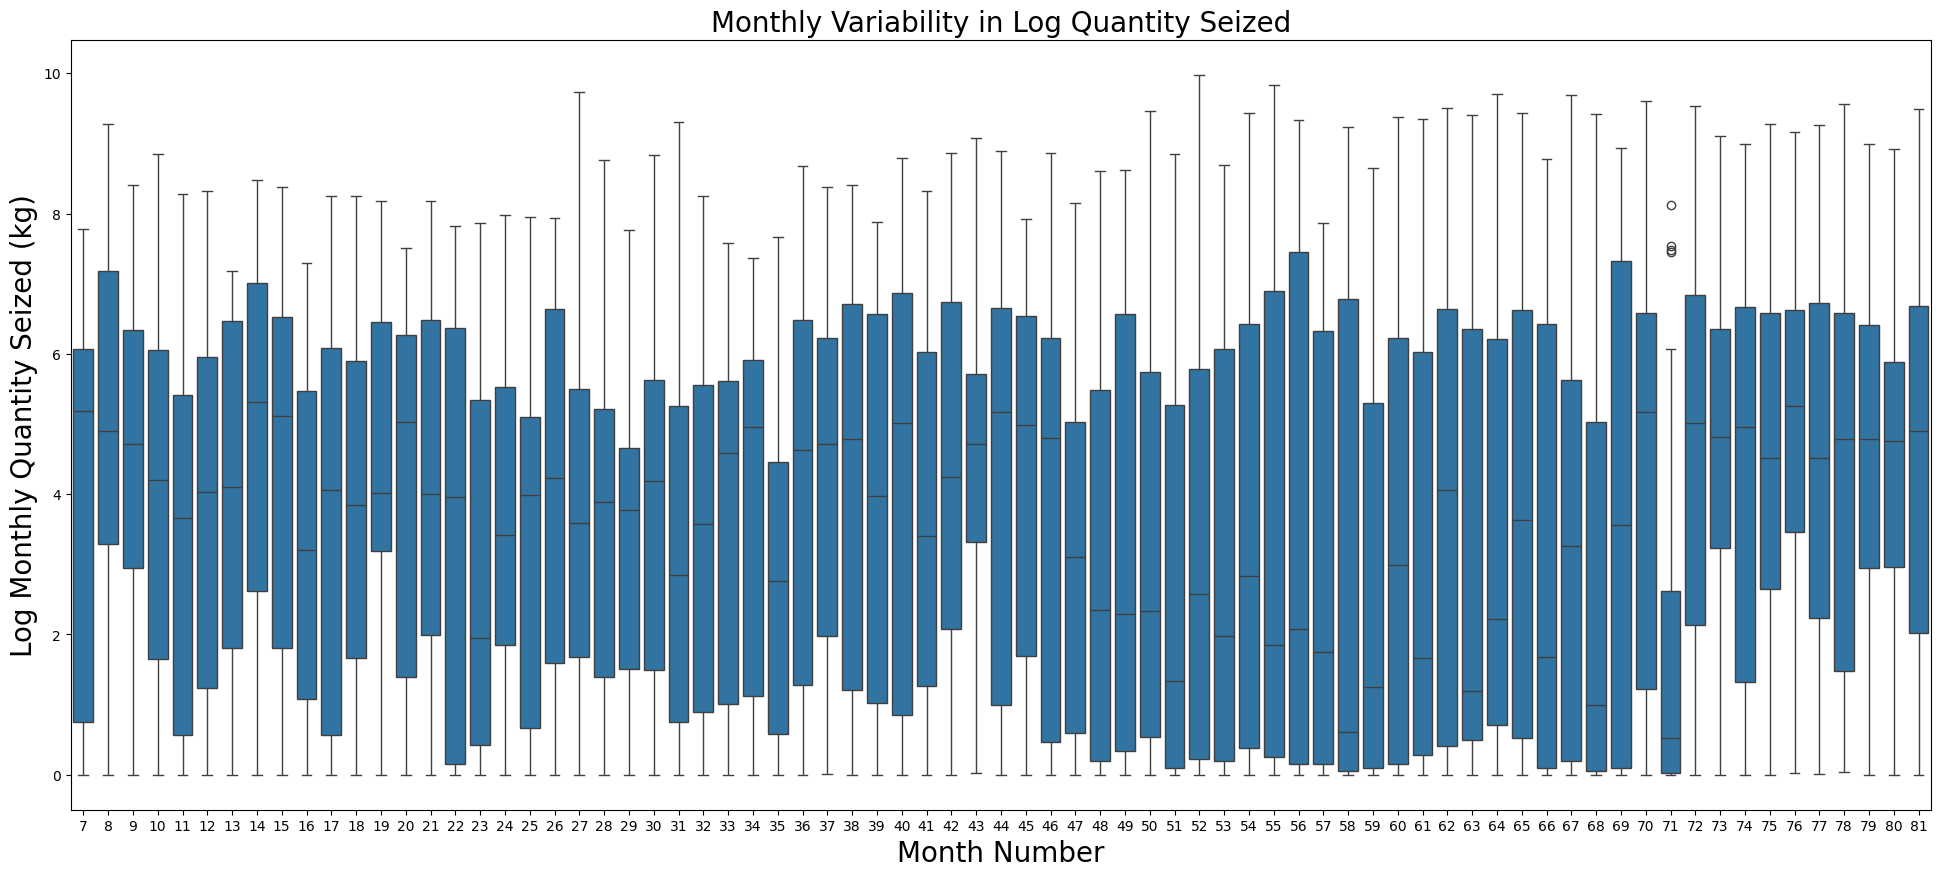

In [ ]:
plt.figure(figsize=(24, 10))
sns.boxplot(x='month_number', y='Log Monthly Quantity Seized (kg)', data=train_encoded)
plt.title("Monthly Variability in Log Quantity Seized", fontsize=20)
plt.xlabel("Month Number", fontsize=20)
plt.ylabel("Log Monthly Quantity Seized (kg)", fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(False)
plt.show()

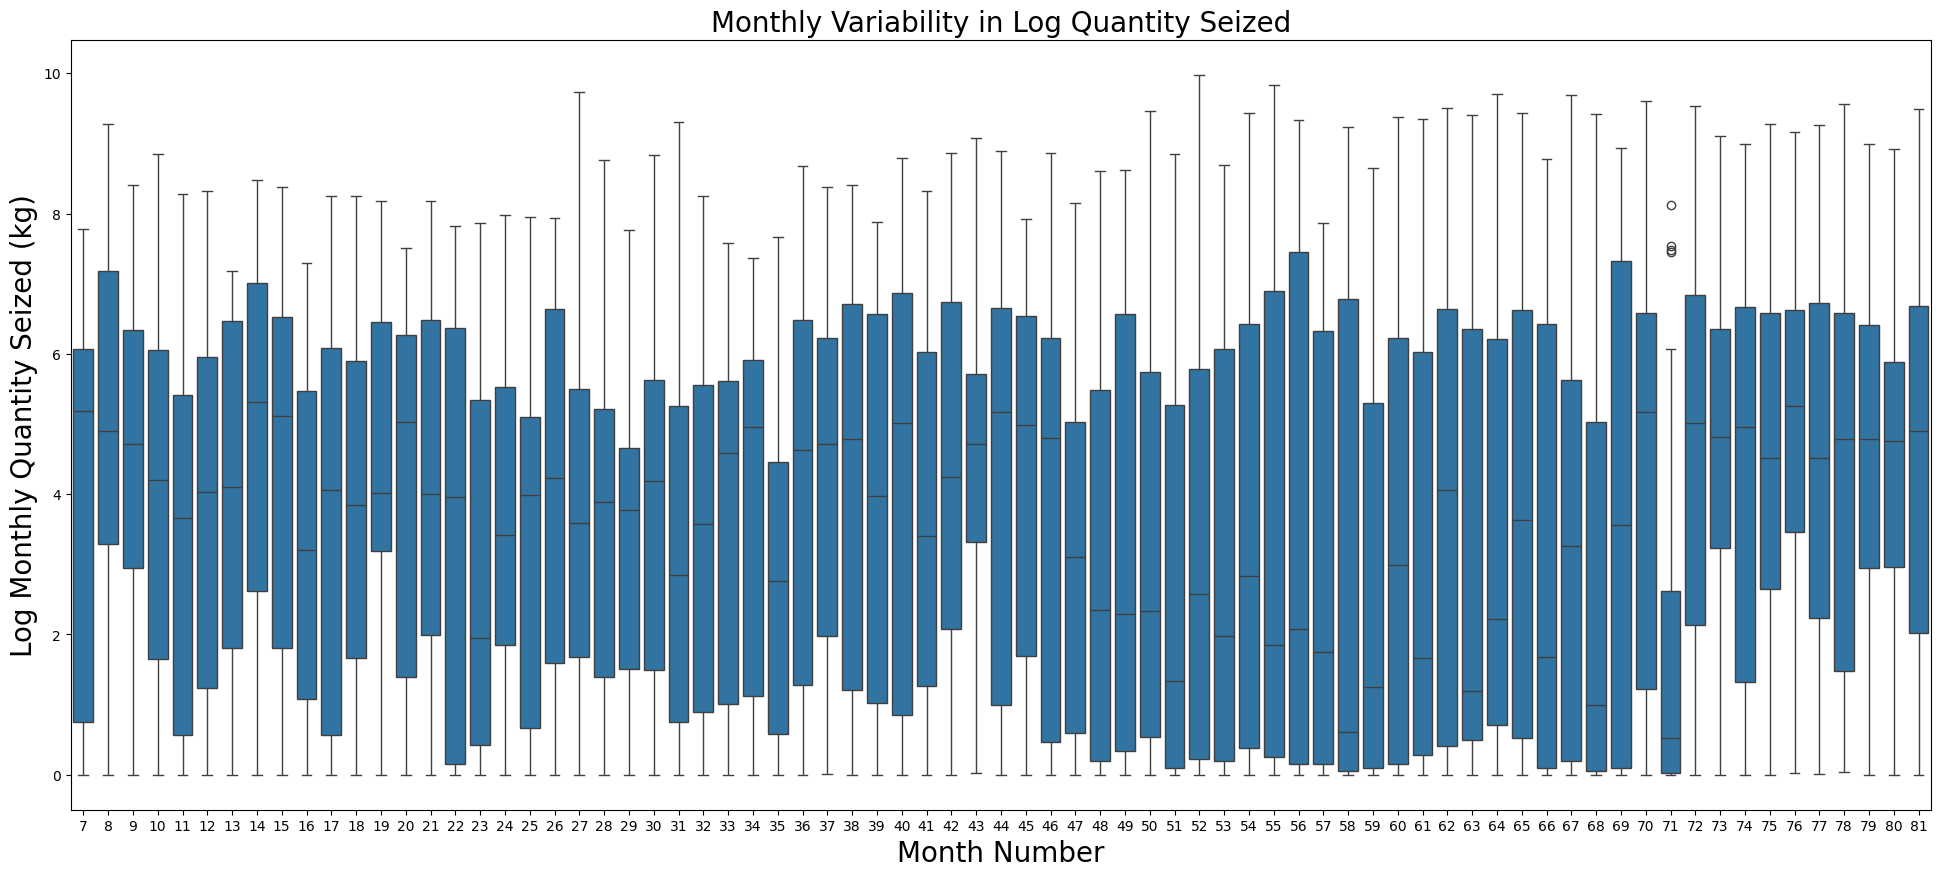

In [ ]:
plt.figure(figsize=(24, 10))
sns.boxplot(x='month_number', y='Log Monthly Quantity Seized (kg)', data=train_encoded)
plt.title("Monthly Variability in Log Quantity Seized", fontsize=20)
plt.xlabel("Month Number", fontsize=20)
plt.ylabel("Log Monthly Quantity Seized (kg)", fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(False)
plt.show()

In [ ]:
cede_features_bg = ['Log Monthly Quantity Seized (kg)', 'Current income (millions pesos)', 'Tax income (millions pesos)', 'Transfers from national entities (millions of pesos)', 'Current expensives linked to institutional performance',
                 'Operating Expenses']
cede_features_cg = ['Log Monthly Quantity Seized (kg)', 'Area km2', 'Rural population', 'Urban population', 'Total population', 'Distance to Bogota', 'Population Density_y', 'Urban to Rural Population Ratio',
                 'Percent Urban Population', 'Percent Rural Population']
cede_features_cv_historical = ['Log Monthly Quantity Seized (kg)', 'Historical Attacks on Population By FARC (1993-2008)', 'Historical Attacks on Population by ELN (1993-2008)',
                 'Historical Attacks on Population by AUC (1993-2008)', 'Historical Antinarcotics Operations (1993-2008)', 'Historical Dismantling Labs (1993-2008)']

cede_features_cv = ['Log Monthly Quantity Seized (kg)', 'Total acts of terrorism',
                 'Total acts against police', 'Total subversive actions', 'Total acts of extorsion', 'Hectares of coca', 'Hectores of coca erdaicted manually ', 'Presence of coca cultivation (dummy)',
                 'Civilians hurt by mines', 'Civilians killed by mines', 'Public force members hurt by mines', 'Public force members killed by mines', 'Events of Abandoned property',
                 'Events of Acts of Terrorism', 'Events of Threats', 'Events of Confinement', 'Events of Sexual Crimes', 'Events of Forced Disappearances', 'Events of Displacement',
                 'Events of Homicide', 'Events of Personal Physical Injuries', 'Events of Personal Pyschological Injuries', 'Events of Mine Explosions', 'Events of Loss of Estate', 'Events of Kiddnapping', 'Events of Torture']

deptfeatures = ['Log Monthly Quantity Seized (kg)', 'month_number',
                             'Border_Department',
       'Ocean_department', 'Department_Antioquia', 'Department_Arauca',
       'Department_Archipiélago de San Andrés, Providencia y Santa Catalina',
       'Department_Atlántico', 'Department_Bogotá D.C.', 'Department_Bolívar',
       'Department_Boyacá', 'Department_Caldas', 'Department_Caquetá',
       'Department_Casanare', 'Department_Cauca', 'Department_Cesar',
       'Department_Chocó', 'Department_Cundinamarca', 'Department_Córdoba',
       'Department_Guainía', 'Department_Guaviare', 'Department_Huila',
       'Department_La Guajira', 'Department_Magdalena', 'Department_Meta',
       'Department_Nariño', 'Department_Norte de Santander',
       'Department_Putumayo', 'Department_Quindío', 'Department_Risaralda',
       'Department_Santander', 'Department_Sucre', 'Department_Tolima',
       'Department_Valle del Cauca', 'Department_Vaupés',
       'Department_Vichada']
socioeconomic_features = ['Percent Population in Urban Areas', 'HDI', 'GDI', 'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births', 'Mean Years Schooling', 'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy', 'Population Density_x', 'Number of Corruption Cases', 'Percent of Total Corruption Cases for That Year', 'Number of Homicides that Year', 'Gini Coefficient', '% Poorest Household (IWI under 30)']
cede_features = ['Current income (millions pesos)', 'Tax income (millions pesos)', 'Transfers from national entities (millions of pesos)', 'Current expensives linked to institutional performance', 'Operating Expenses', 'Area km2', 'Rural population', 'Urban population', 'Total population', 'Distance to Bogota', 'Population Density_y', 'Urban to Rural Population Ratio', 'Percent Urban Population', 'Percent Rural Population', 'Historical Attacks on Population By FARC (1993-2008)', 'Historical Attacks on Population by ELN (1993-2008)', 'Historical Attacks on Population by AUC (1993-2008)', 'Historical Antinarcotics Operations (1993-2008)', 'Historical Dismantling Labs (1993-2008)', 'Total acts of terrorism', 'Total acts against police', 'Total subversive actions', 'Total acts of extorsion', 'Hectares of coca', 'Hectores of coca erdaicted manually ', 'Presence of coca cultivation (dummy)', 'Civilians hurt by mines', 'Civilians killed by mines', 'Public force members hurt by mines', 'Public force members killed by mines', 'Events of Abandoned property', 'Events of Acts of Terrorism', 'Events of Threats', 'Events of Confinement', 'Events of Sexual Crimes', 'Events of Forced Disappearances', 'Events of Displacement', 'Events of Homicide', 'Events of Personal Physical Injuries', 'Events of Personal Pyschological Injuries', 'Events of Mine Explosions', 'Events of Loss of Estate', 'Events of Kiddnapping', 'Events of Torture']
lag_features = ['Lagged_Log_Monthly_Quantity_Seized_1', 'Lagged_Log_Monthly_Quantity_Seized_2', 'Lagged_Log_Monthly_Quantity_Seized_3', 'Lagged_Log_Monthly_Quantity_Seized_4', 'Lagged_Log_Monthly_Quantity_Seized_5', 'Lagged_Log_Monthly_Quantity_Seized_6', 'Rolling_3M_Log_Monthly_Quantity', 'Rolling_6M_Log_Monthly_Quantity', 'Rolling_3M_Std_Log_Monthly_Quantity', 'Rolling_6M_Std_Log_Monthly_Quantity', 'Rolling_3M_Min_Log_Monthly_Quantity', 'Rolling_6M_Min_Log_Monthly_Quantity', 'Rolling_3M_Max_Log_Monthly_Quantity', 'Rolling_6M_Max_Log_Monthly_Quantity', 'Rolling_3M_Range_Log_Monthly_Quantity', 'Rolling_6M_Range_Log_Monthly_Quantity', 'EMA_3M_Log_Monthly_Quantity', 'EMA_6M_Log_Monthly_Quantity', 'Momentum_3_6', 'Cumulative_Log_Monthly_Quantity_Seized_Per_Year', 'season_Spring', 'season_Summer', 'season_Winter', 'Growth_Rate_Lag_1_2', 'Growth_Rate_Lag_2_3', 'Growth_Rate_Lag_1_3']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Select relevant columns for correlation (excluding 'month_number' as it's an index)
def getCorrMatrix(features_to_analyze, final_train, fig_size1, fig_size2):
  correlation_matrix = final_train[features_to_analyze].corr()

  # Plot the heatmap
  plt.figure(figsize=(fig_size1, fig_size2))
  sns.heatmap(
      correlation_matrix,
      annot=True,         # Annotate each cell with the correlation value
      fmt=".2f",          # Format numbers to 2 decimal places
      cmap='coolwarm',    # Color scheme for the heatmap
      square=True,
      cbar=True
  )
  plt.title("Feature Correlation Matrix")
  plt.show()



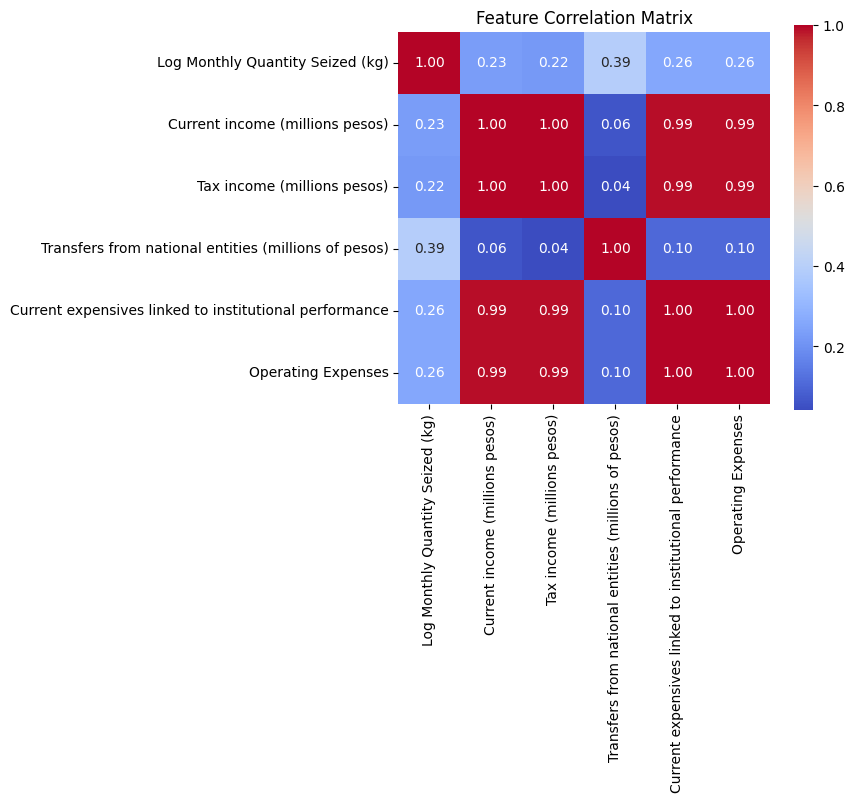

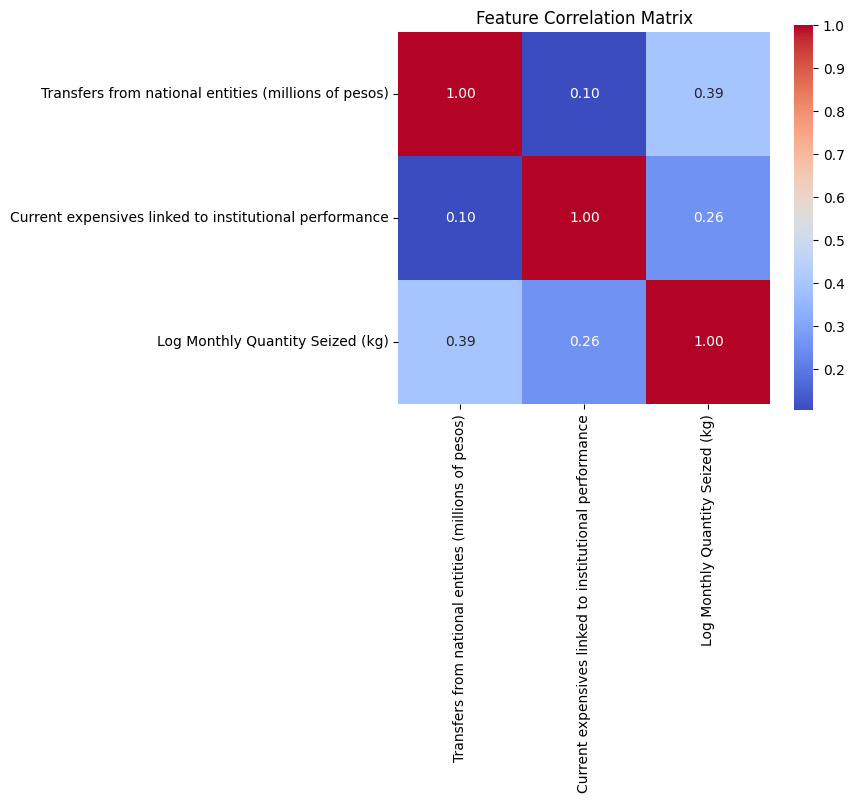

In [ ]:
getCorrMatrix(cede_features_bg, final_train, 6, 5)
cede_features_bg_to_keep = ['Transfers from national entities (millions of pesos)', 'Current expensives linked to institutional performance']
getCorrMatrix((cede_features_bg_to_keep + ['Log Monthly Quantity Seized (kg)']), final_train, 6, 5)

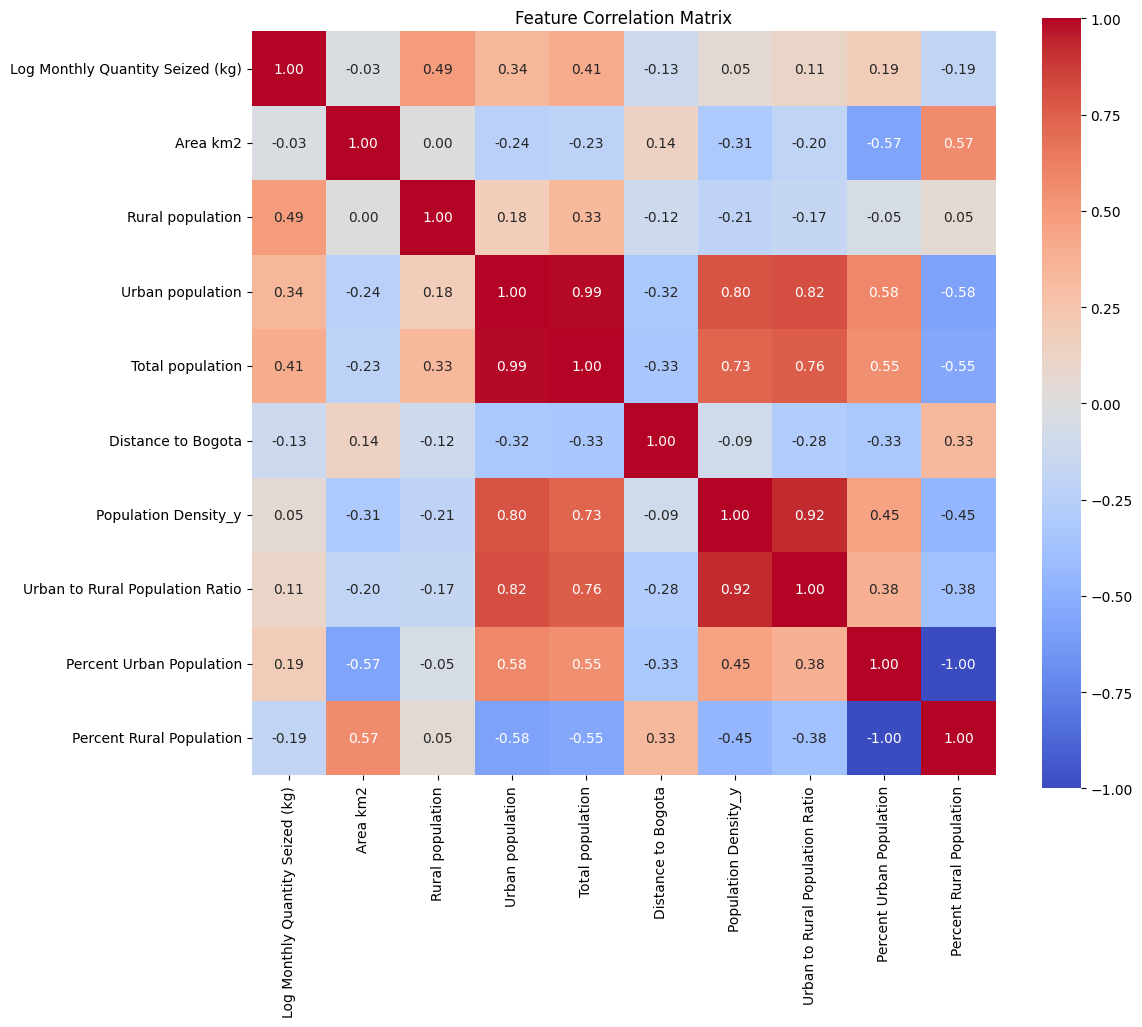

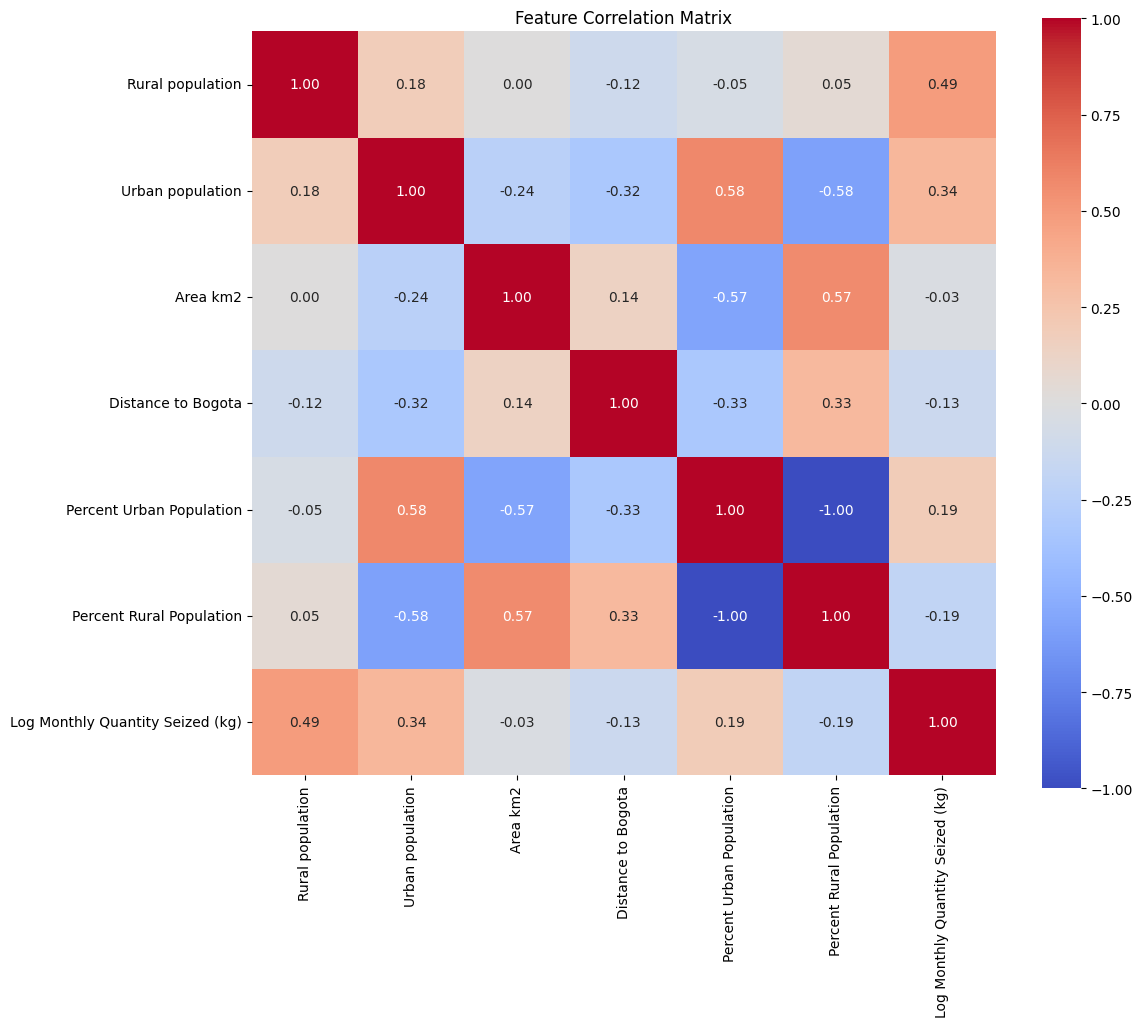

In [ ]:
getCorrMatrix(cede_features_cg, final_train, 12, 10)
cede_features_cg_to_keep = ['Rural population', 'Urban population', 'Area km2', 'Distance to Bogota',  'Percent Urban Population', 'Percent Rural Population']
getCorrMatrix((cede_features_cg_to_keep + ['Log Monthly Quantity Seized (kg)']), final_train, 12, 10)

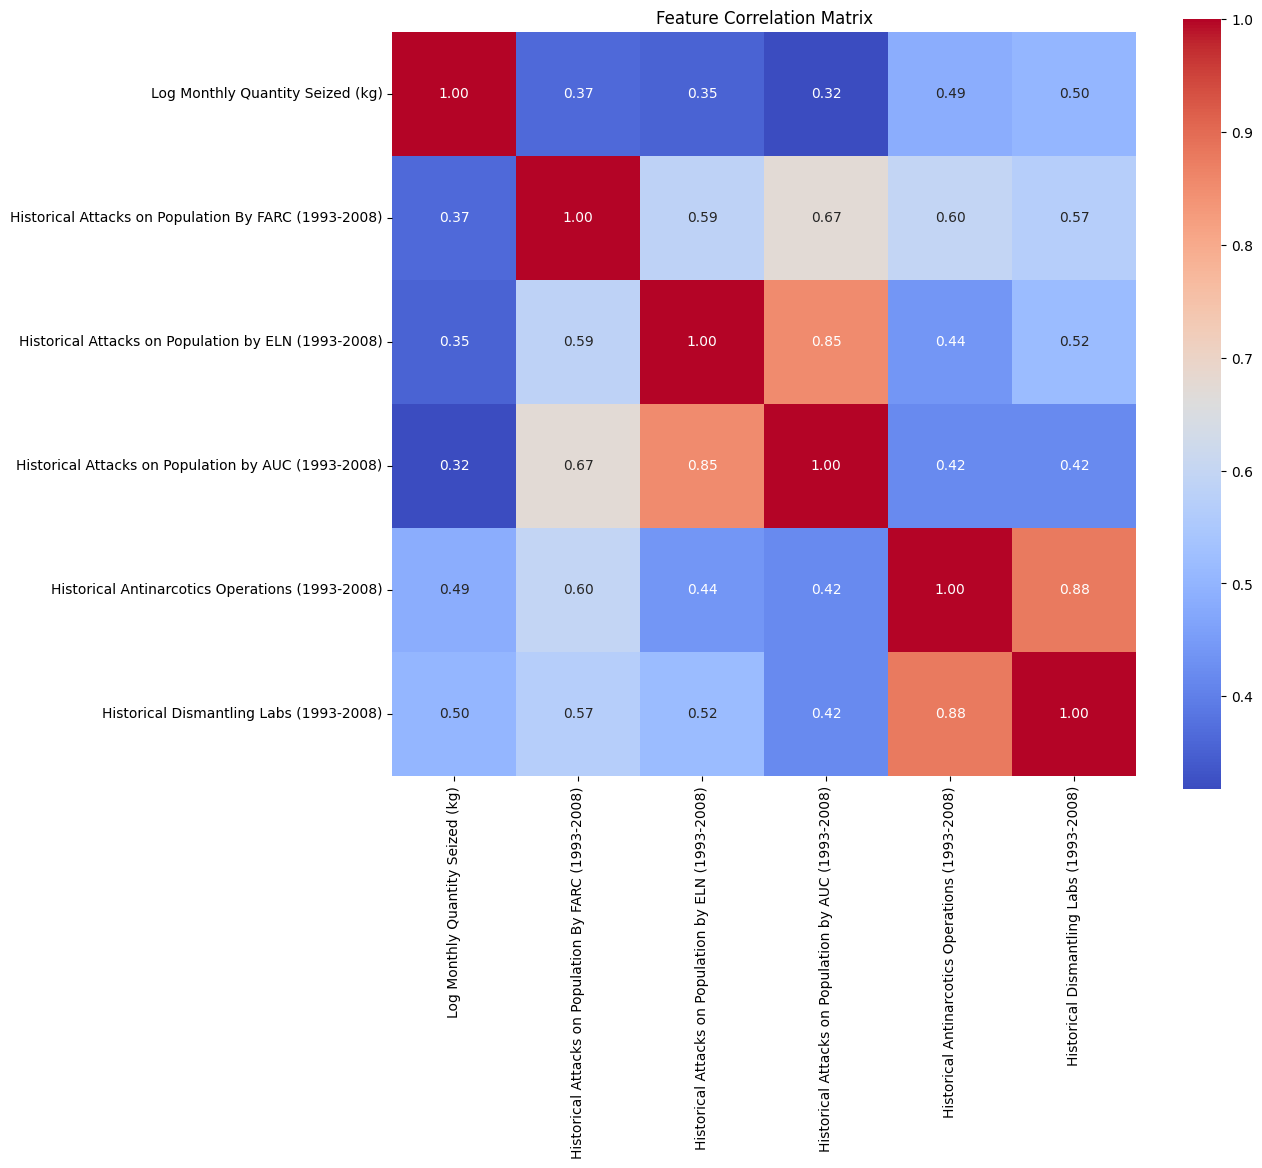

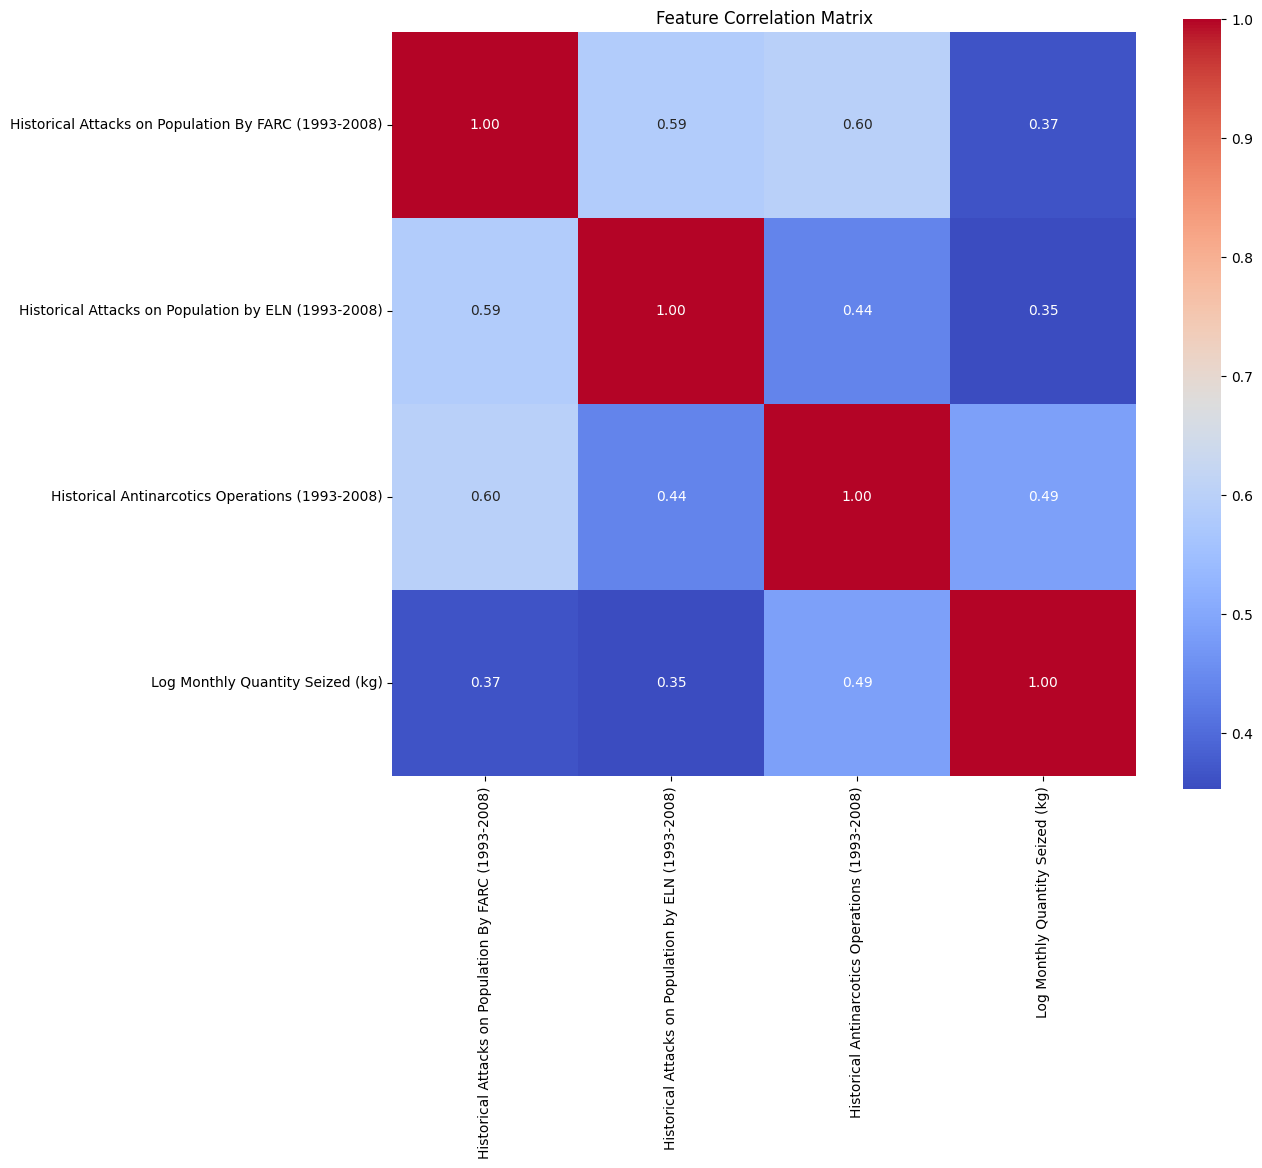

In [ ]:
getCorrMatrix(cede_features_cv_historical, final_train, 12, 10)
cede_features_cv_historical_to_keep = ["Historical Attacks on Population By FARC (1993-2008)", "Historical Attacks on Population by ELN (1993-2008)",
                                       "Historical Antinarcotics Operations (1993-2008)"]
getCorrMatrix((cede_features_cv_historical_to_keep + ['Log Monthly Quantity Seized (kg)']), final_train, 12, 10)

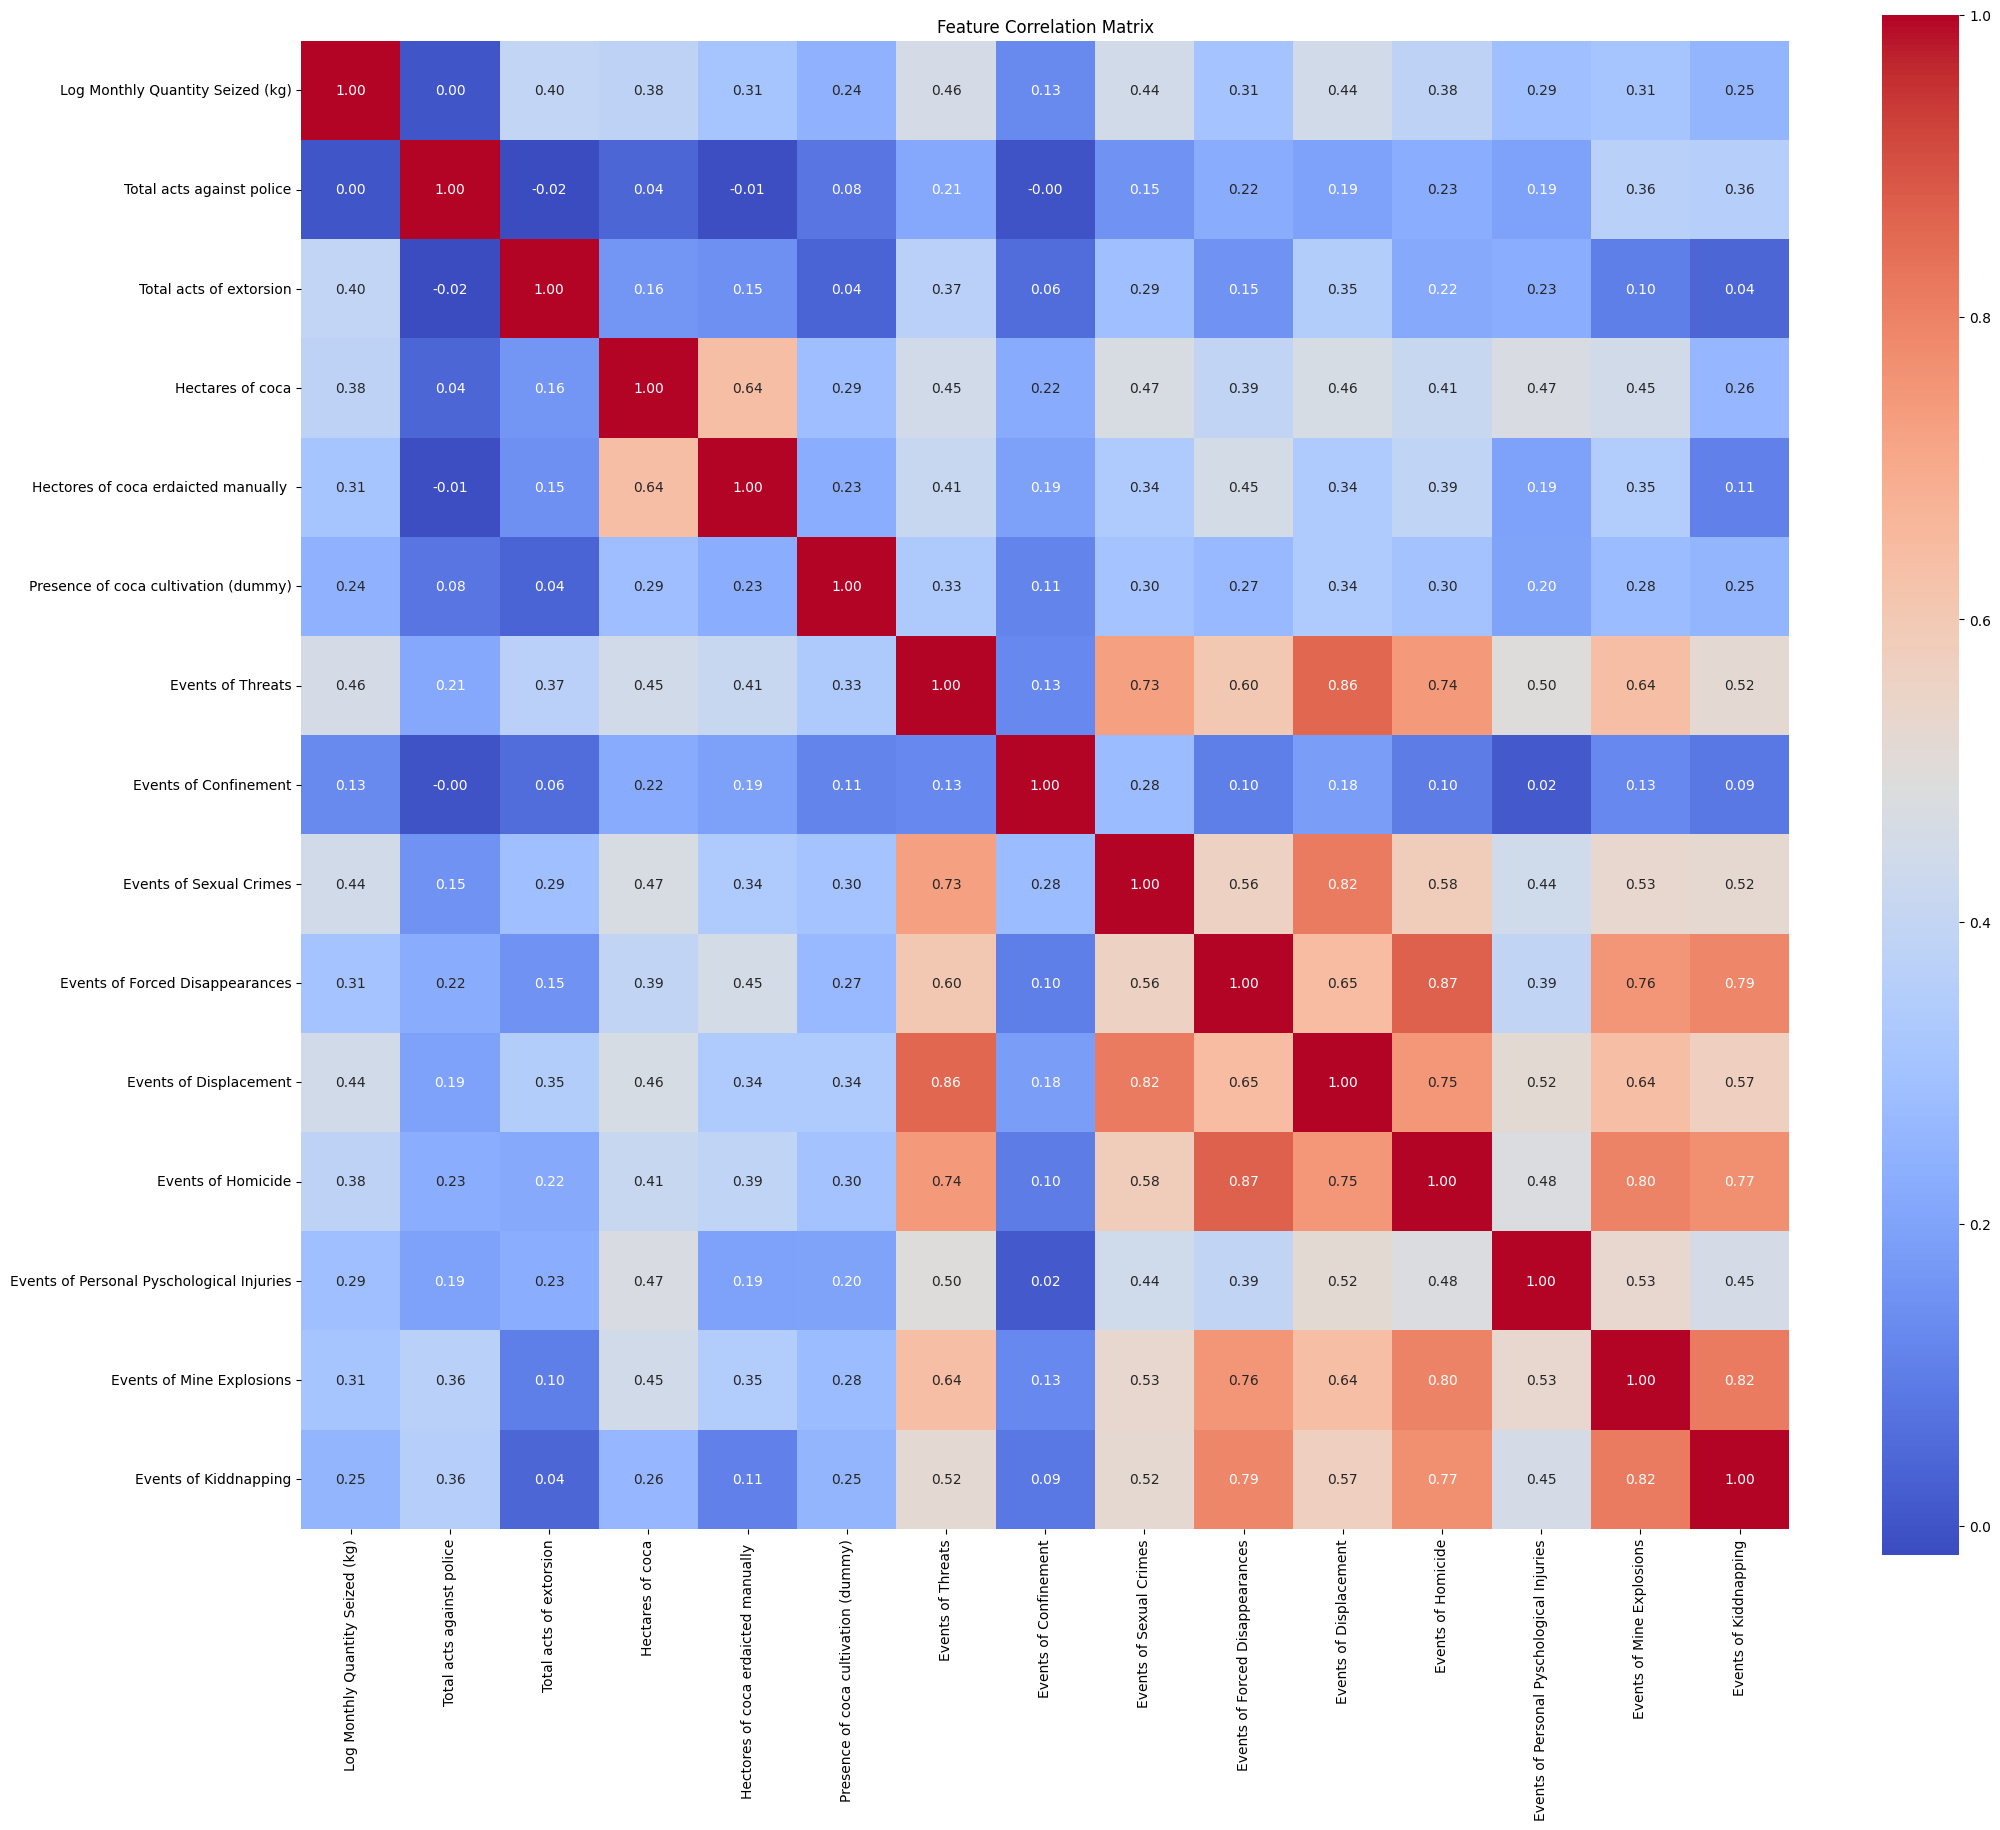

In [ ]:
#cede_features_cv.remove('Log Monthly Quantity Seized (kg)')
#getCorrMatrix((cede_features_cv + ['Log Monthly Quantity Seized (kg)']), final_train, 24, 20)



cede_features_cv_to_keep = [
 'Total acts against police',
 'Total acts of extorsion',
 'Hectares of coca',
 'Hectores of coca erdaicted manually ',
 'Presence of coca cultivation (dummy)',
 'Events of Threats',
 'Events of Confinement',
 'Events of Sexual Crimes',
 'Events of Forced Disappearances',
 'Events of Displacement',
 'Events of Homicide',
 'Events of Personal Pyschological Injuries',
 'Events of Mine Explosions',
 'Events of Kiddnapping']
getCorrMatrix((['Log Monthly Quantity Seized (kg)'] + cede_features_cv_to_keep), final_train, 24, 20)

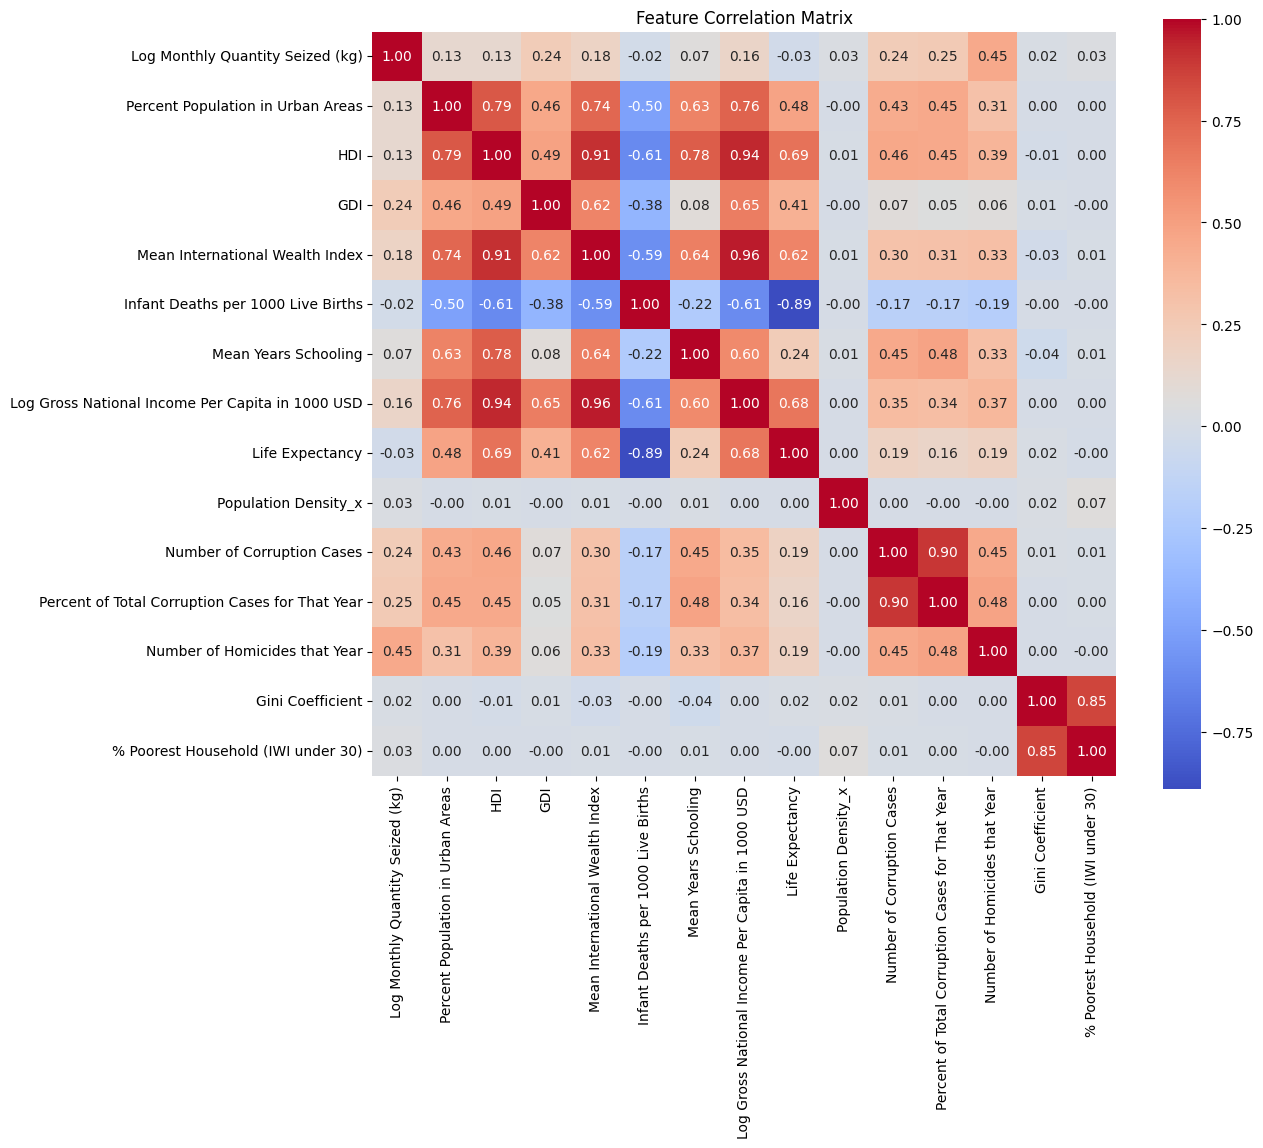

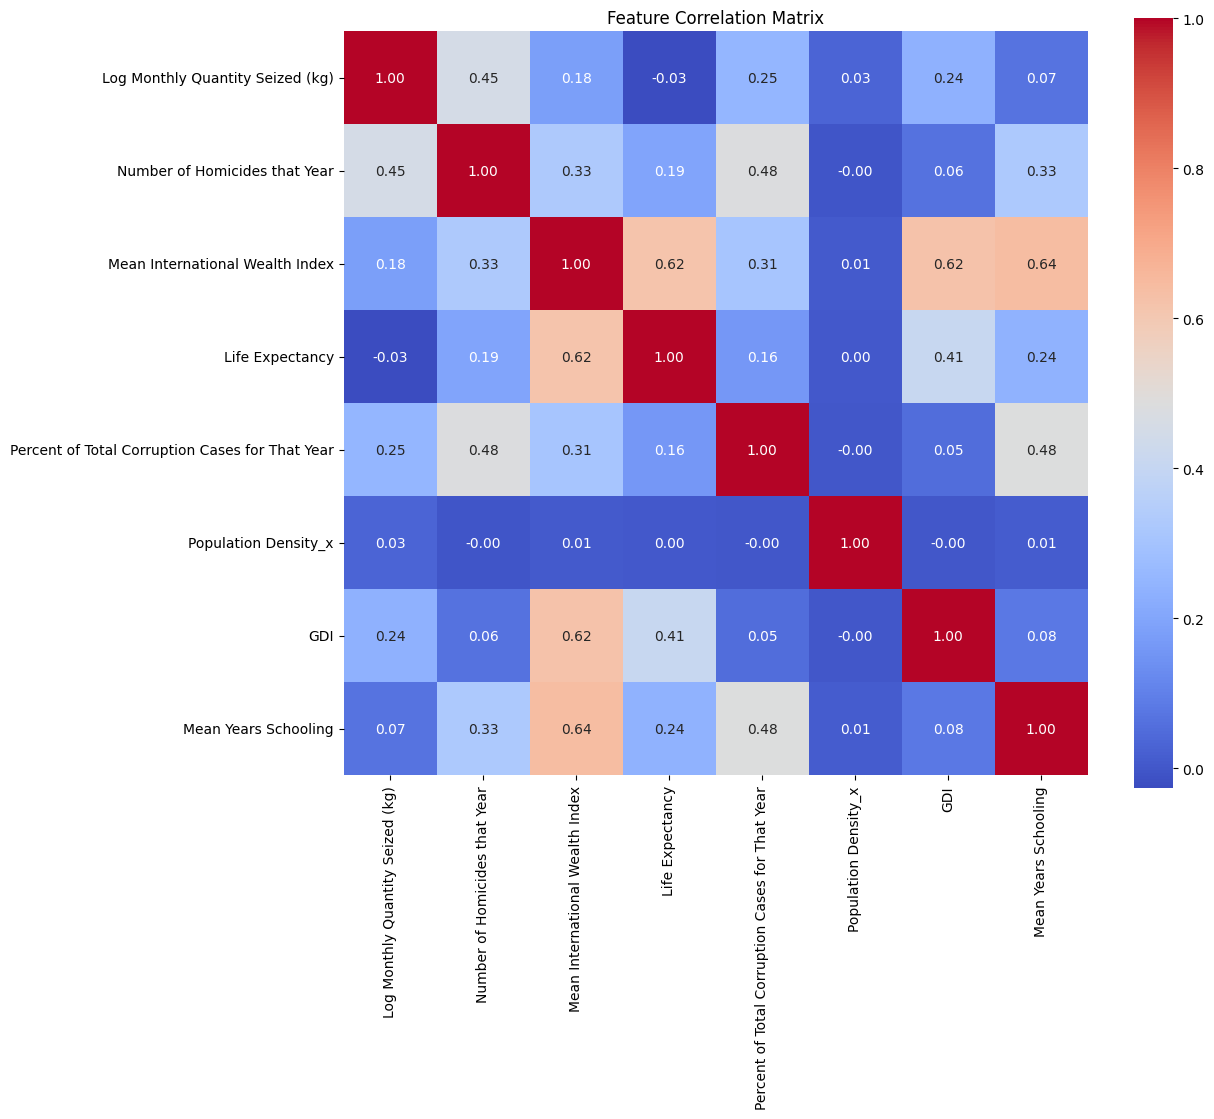

In [ ]:
getCorrMatrix(['Log Monthly Quantity Seized (kg)'] + socioeconomic_features, final_train, 12, 10)
socioeconomic_features_to_keep = ['Number of Homicides that Year', 'Mean International Wealth Index', 'Life Expectancy', 'Percent of Total Corruption Cases for That Year', 'Population Density_x', 'GDI', 'Mean Years Schooling' ]
getCorrMatrix(['Log Monthly Quantity Seized (kg)'] + socioeconomic_features_to_keep, final_train, 12, 10)

In [ ]:
getCorrMatrix(time_features, final_train, 18, 15)

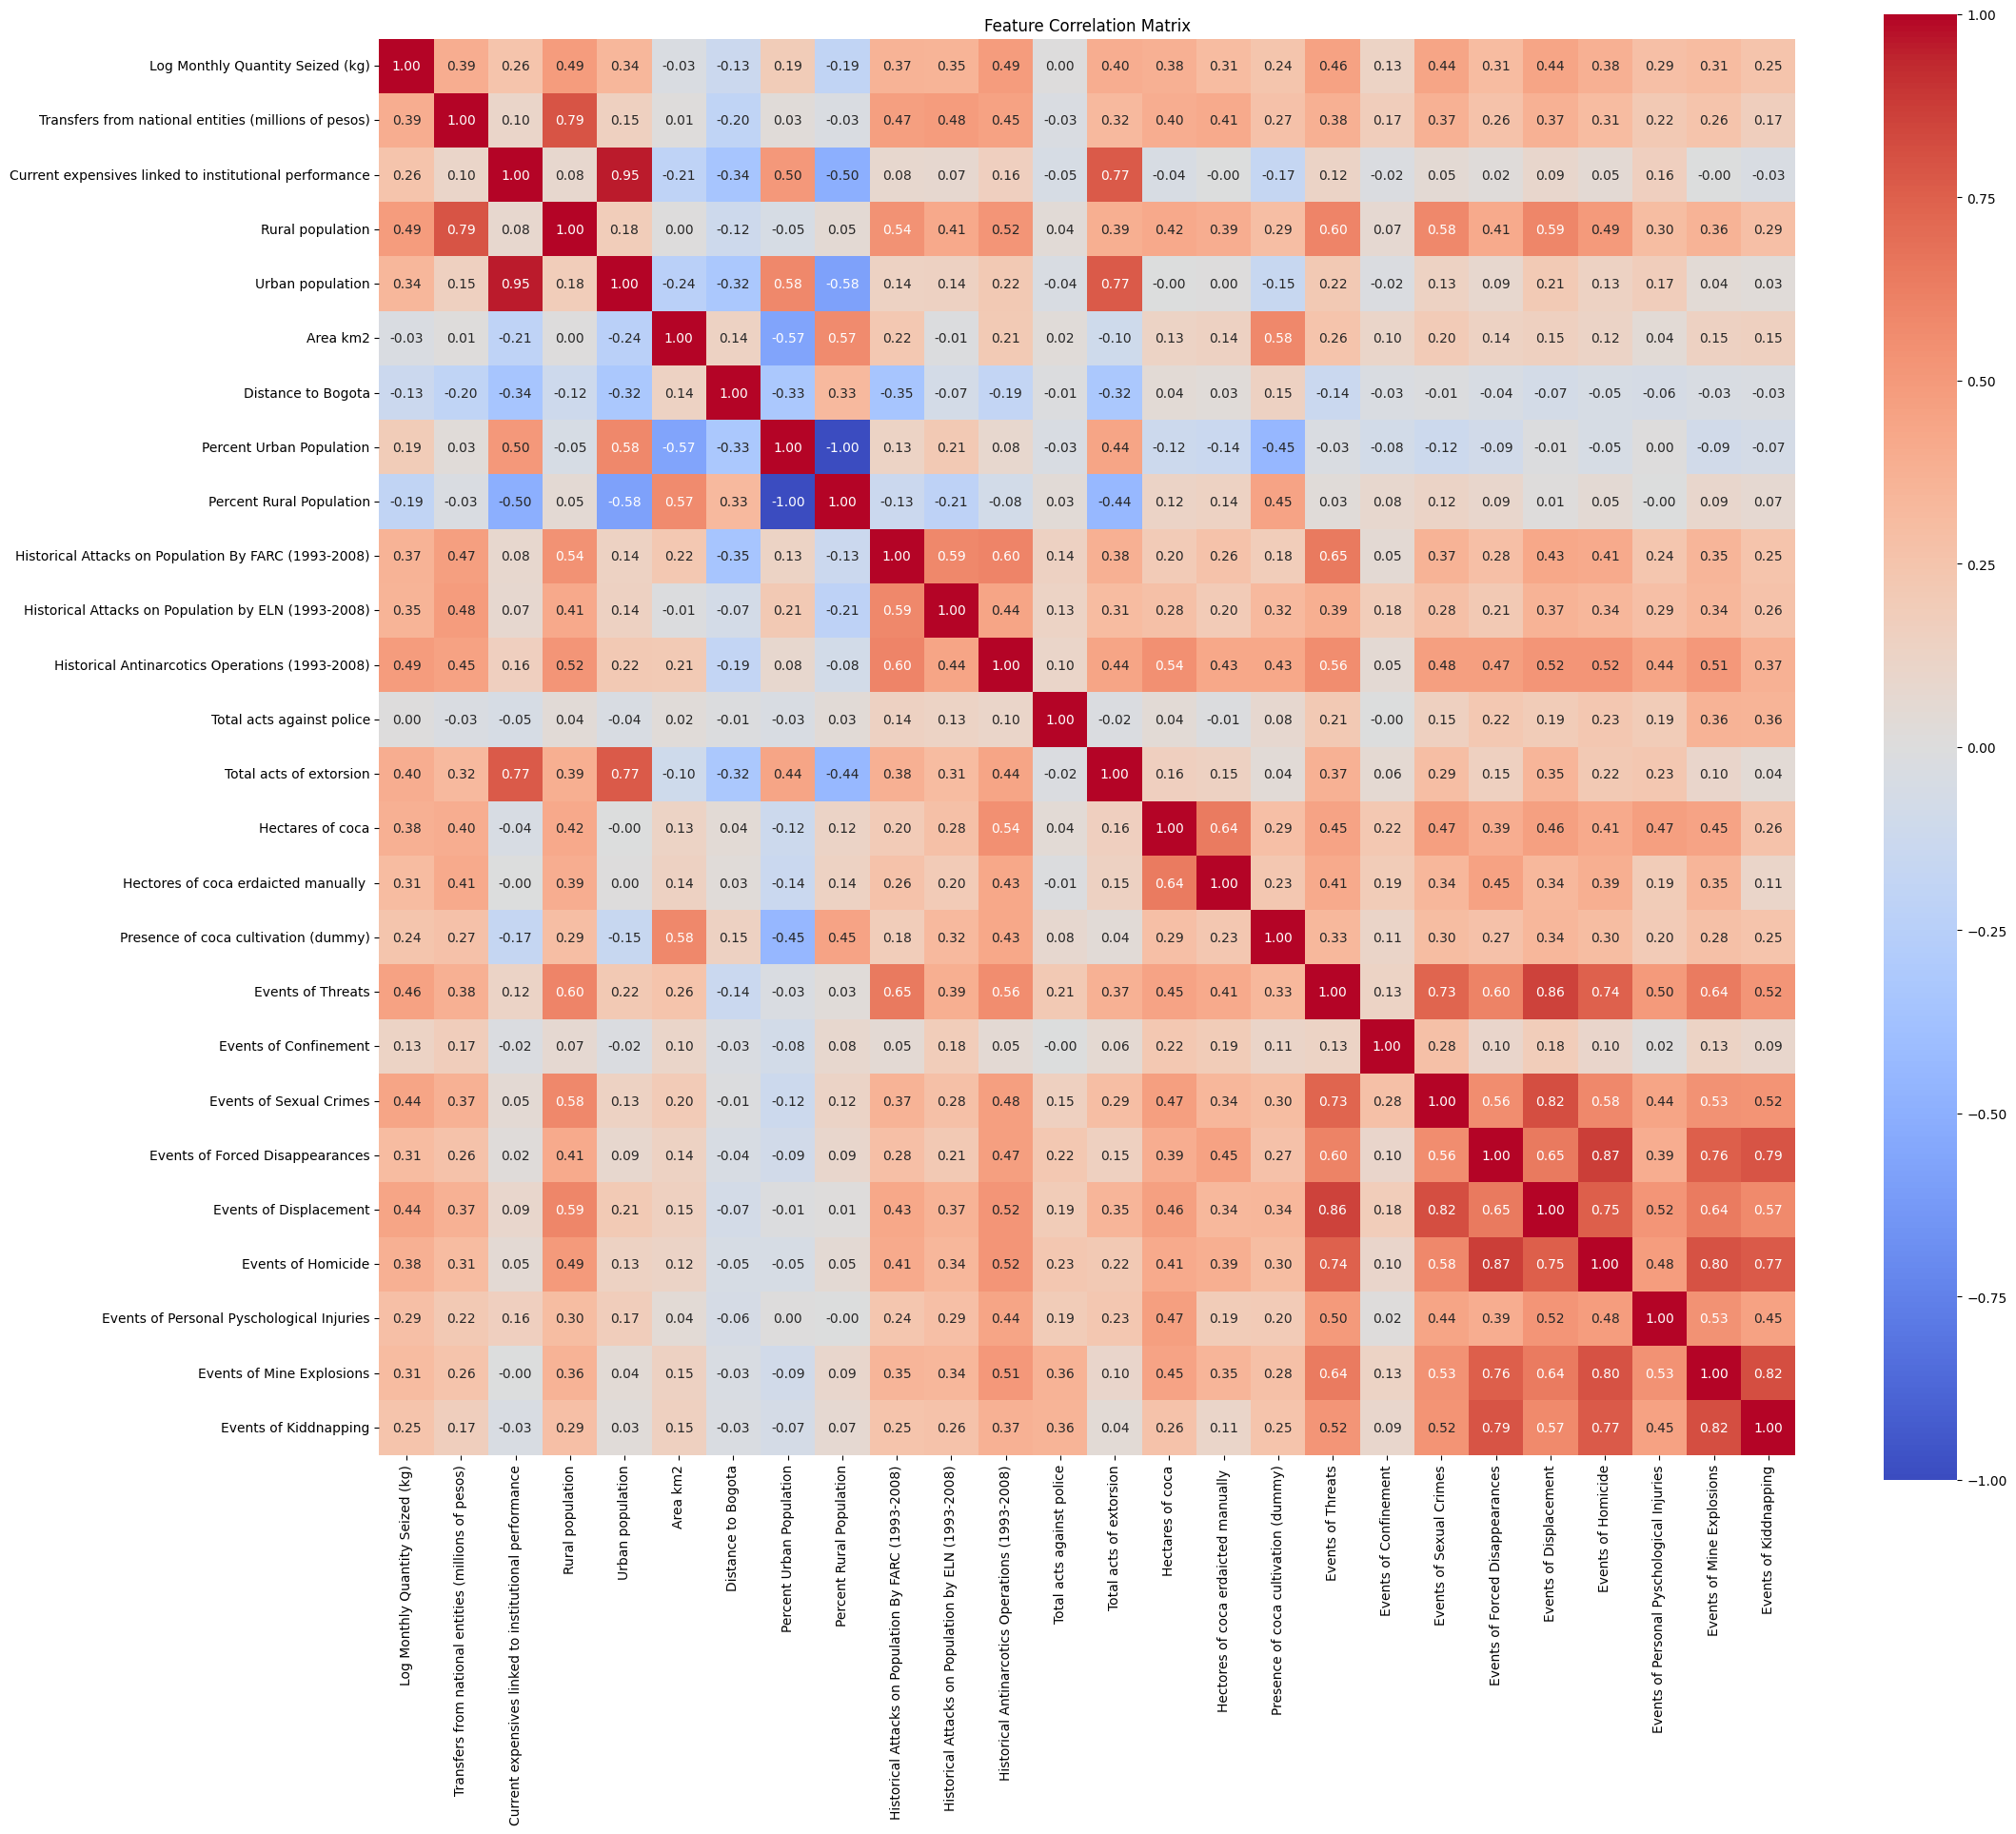

In [ ]:
cede_features = cede_features_bg_to_keep + cede_features_cg_to_keep + cede_features_cv_historical_to_keep + cede_features_cv_to_keep
getCorrMatrix((['Log Monthly Quantity Seized (kg)'] + cede_features), final_train, 24, 20)

In [ ]:

# Split the data
X_train = final_train[cede_features]
y_train = final_train['Log Monthly Quantity Seized (kg)']
X_test = test_encoded[cede_features]
y_test = test_encoded['Log Monthly Quantity Seized (kg)']

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

mse = mean_squared_error(y_test, model.predict(X_test))
print(f"Mean Squared Error: {mse}")

# Get feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': cede_features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
feature_importance.head(25)


Mean Squared Error: 5.752275843041625


,Feature,Coefficient
3,Urban population,1.253933
16,Presence of coca cultivation (dummy),0.639163
2,Rural population,0.565107
1,Current expensives linked to institutional per...,-0.562650
19,Events of Sexual Crimes,0.559680
20,Events of Forced Disappearances,-0.518927
25,Events of Kiddnapping,0.413472
11,Historical Dismantling Labs (1993-2008),0.399875
4,Area km2,-0.382049
21,Events of Displacement,-0.347396


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Split data
X_train = final_train[cede_features]
y_train = final_train['Log Monthly Quantity Seized (kg)']
X_test = test_encoded[cede_features]
y_test = test_encoded['Log Monthly Quantity Seized (kg)']

# Train Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, model.predict(X_test))
print(f"Mean Squared Error: {mse}")

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': cede_features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select the top 25 features
top_25_features = feature_importance.head(25)

# Display the top 25 features
top_25_features.head(25)


Mean Squared Error: 3.784814555245161


,Feature,Importance
19,Events of Sexual Crimes,0.358607
3,Urban population,0.193625
10,Historical Antinarcotics Operations (1993-2008),0.098423
2,Rural population,0.045743
14,Hectares of coca,0.040980
13,Total acts of extorsion,0.038718
15,Hectores of coca erdaicted manually,0.032453
1,Current expensives linked to institutional per...,0.020781
5,Distance to Bogota,0.020278
22,Events of Homicide,0.019863


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Split data
X_train = final_train[socioeconomic_features_to_keep]
y_train = final_train['Log Monthly Quantity Seized (kg)']
X_test = test_encoded[socioeconomic_features_to_keep]
y_test = test_encoded['Log Monthly Quantity Seized (kg)']

# Train Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, model.predict(X_test))
print(f"Mean Squared Error: {mse}")

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': socioeconomic_features_to_keep,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select the top 25 features
top_25_features = feature_importance.head(25)

# Display the top 25 features
top_25_features.head(25)


Mean Squared Error: 7.159429133063419


,Feature,Importance
0,Number of Homicides that Year,0.433085
4,Population Density_x,0.242050
2,Life Expectancy,0.108223
1,Mean International Wealth Index,0.064879
6,Mean Years Schooling,0.062080
5,GDI,0.052795
3,Percent of Total Corruption Cases for That Year,0.036888


In [ ]:
#features = socioeconomic_features_to_keep + cede_features
#getCorrMatrix((['Log Monthly Quantity Seized (kg)'] + features), final_train, 24, 20)
features_to_keep = ['Number of Homicides that Year', 'Mean International Wealth Index',
 'Life Expectancy',
 'Percent of Total Corruption Cases for That Year',
 'GDI',
 'Transfers from national entities (millions of pesos)',
 'Current expensives linked to institutional performance',
 'Rural population',
 'Urban population',
 'Area km2',
 'Distance to Bogota',
 'Percent Urban Population',
 'Percent Rural Population',
 'Historical Attacks on Population By FARC (1993-2008)',
 'Historical Attacks on Population by ELN (1993-2008)',
 'Historical Antinarcotics Operations (1993-2008)',
 'Total acts against police',
 'Total acts of extorsion',
 'Hectares of coca',
 'Hectores of coca erdaicted manually ',
 'Presence of coca cultivation (dummy)',
 'Events of Threats',
 'Events of Confinement',
 'Events of Sexual Crimes',
 'Events of Forced Disappearances',
 'Events of Displacement',
 'Events of Personal Pyschological Injuries',
 'Events of Mine Explosions',
 'Events of Kiddnapping']

#getCorrMatrix((['Log Monthly Quantity Seized (kg)'] + features_to_keep), final_train, 24, 20)

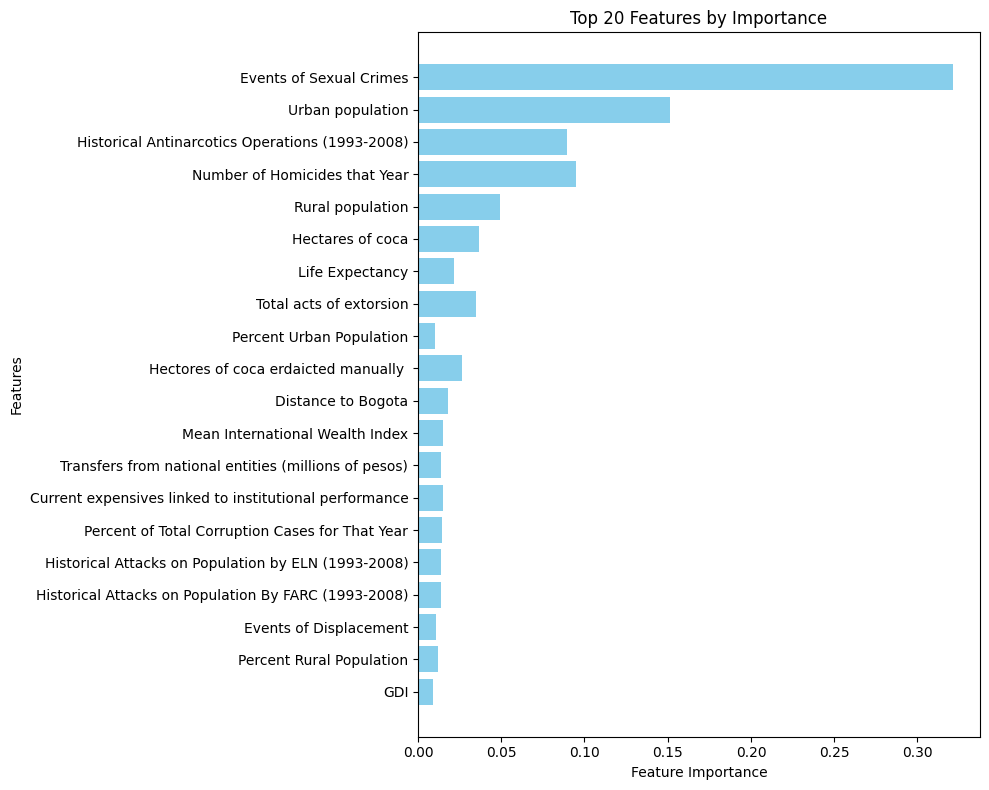

                                              Feature  Rank  Importance
23                            Events of Sexual Crimes     1    0.321513
8                                    Urban population     2    0.151190
15    Historical Antinarcotics Operations (1993-2008)     3    0.089377
0                       Number of Homicides that Year     4    0.095116
7                                    Rural population     5    0.049194
18                                   Hectares of coca     6    0.036444
2                                     Life Expectancy     7    0.021492
17                            Total acts of extorsion     8    0.034655
11                           Percent Urban Population     9    0.010153
19               Hectores of coca erdaicted manually     10    0.026154
10                                 Distance to Bogota    11    0.017770
1                     Mean International Wealth Index    12    0.015122
5   Transfers from national entities (millions of ...    13    0

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
#@CITATION: CODE ADAPTED FROM CHAT GPT
# Initialize the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Perform Recursive Feature Elimination
rfe = RFE(estimator=rf, n_features_to_select=1, step=1)
rfe.fit(X_train, y_train)

# Get feature importances from the fitted Random Forest model
rf.fit(X_train, y_train)
feature_importances = rf.feature_importances_

# Create a DataFrame to store rankings and feature importances
rfe_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': rfe.ranking_,
    'Importance': feature_importances
}).sort_values(by='Rank')

# Select the top 20 features
top_20_features = rfe_results.head(20)

# Plot the top 20 features
plt.figure(figsize=(10, 8))
plt.barh(top_20_features['Feature'], top_20_features['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 20 Features by Importance')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

# Print top 20 feature rankings
print(top_20_features)


In [ ]:
#getCorrMatrix(socioeconomic_features, final_train, 12, 10)
#getCorrMatrix(time_features, final_train, 18, 15)
#getCorrMatrix(department_features, final_train, 24, 20)

In [ ]:
features_to_keep = features_to_keep + deptfeatures + lag_features + ['month_number', 'Log Monthly Quantity Seized (kg)']
features_to_keep = pd.DataFrame(features_to_keep)
features_to_keep.drop_duplicates(inplace=True)
features_to_keep.tail(50)

,0
41,Department_Caquetá
42,Department_Casanare
43,Department_Cauca
44,Department_Cesar
45,Department_Chocó
46,Department_Cundinamarca
47,Department_Córdoba
48,Department_Guainía
49,Department_Guaviare
50,Department_Huila


In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def XGBoost(train_encoded, test_encoded):
  #split train and test sets into features and target var
  X_train = train_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_train = train_encoded['Log Monthly Quantity Seized (kg)']
  X_test = test_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_test = test_encoded['Log Monthly Quantity Seized (kg)']


  xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=800, learning_rate=0.01, max_depth=6, min_child_weight=10, colsample_bytree=1, colsample_bylevel=1, colsample_bynode=1.0, alpha=0.1)

  # Fit the model
  xgb_model.fit(X_train, y_train)


  # Make predictions on the training set
  y_train_pred = xgb_model.predict(X_train)

  # Make predictions on the test set
  y_pred = xgb_model.predict(X_test)

  # Evaluate the model on the training set
  mse_train = mean_squared_error(y_train, y_train_pred)
  train_r2 = r2_score(y_train, y_train_pred)

  # Evaluate the model on the test set
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  # Print the results
  print("XGBoost")
  print(f"Training MSE: {mse_train}")
  print(f"Testing Mean Squared Error (MSE): {mse}")
  print(f"R-squared (R²): {r2}")

  #PLOTS

  # Residual Plot and Prediction vs Actual
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Residual Plot
  residuals = y_test - y_pred
  sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
  axes[0].axhline(0, color='r', linestyle='--', lw=2)
  axes[0].set_xlabel("Predicted Values")
  axes[0].set_ylabel("Residuals")
  axes[0].set_title("Residual Plot")

  # Prediction vs Actual
  sns.scatterplot(x=y_test, y=y_pred, ax=axes[1])
  axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  axes[1].set_xlabel("Actual Log Monthly Quantity Seized (kg)")
  axes[1].set_ylabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Predicted vs Actual")

  plt.tight_layout()
  plt.show()

  # Distribution of Predictions and Error Distribution
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Distribution of Predictions
  sns.histplot(y_pred, bins=30, kde=True, ax=axes[0])
  axes[0].set_xlabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[0].set_title("Distribution of Predicted Log Monthly Quantity Seized (kg)")

  # Error Distribution
  sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
  axes[1].set_xlabel("Residuals (Error)")
  axes[1].set_title("Distribution of Prediction Errors (Residuals)")

  plt.tight_layout()
  plt.show()

  # Feature Importance and Actual vs Predicted Comparison on one line
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Top 12 Feature Importances
  importances = xgb_model.feature_importances_
  feature_importance = pd.Series(importances, index=X_train.columns)
  feature_importance.nlargest(12).plot(kind='barh', ax=axes[0])
  axes[0].set_title("Top 12 Feature Importances in XGBoost Model")
  axes[0].set_xlabel("Importance")
  axes[0].set_ylabel("Feature")

  # Comparison of Actual vs Predicted
  comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
  comparison_df.sort_index(inplace=True)

  axes[1].plot(comparison_df.index, comparison_df['Actual'], label='Actual', color='blue', linewidth=2)
  axes[1].plot(comparison_df.index, comparison_df['Predicted'], label='Predicted', color='orange', linewidth=2)
  axes[1].set_xlabel("Index")
  axes[1].set_ylabel("Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Actual vs Predicted Log Monthly Quantity Seized (kg)")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

  results_df = X_test.copy()
  results_df['Actual'] = y_test
  results_df['Predicted'] = y_pred
  results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

  # Identify the department for each row
  department_cols = [col for col in results_df.columns if col.startswith('Department_')]
  results_df['Department'] = results_df[department_cols].idxmax(axis=1).str.replace('Department_', '')

  # Calculate MSE for each department
  mse_per_department = results_df.groupby('Department').apply(lambda x: mean_squared_error(x['Actual'], x['Predicted'])).reset_index()
  mse_per_department.columns = ['Department', 'MSE']

  # Print the MSE per department
  mse_per_department.sort_values(by='MSE', ascending=False, inplace=True)
  print(mse_per_department)
  departments = results_df['Department'].unique()
  for department in departments:
      dept_data = results_df[results_df['Department'] == department].sort_values(by='month_number')

      plt.figure(figsize=(10, 5))
      plt.plot(dept_data['month_number'], dept_data['Actual'], label='Actual', color='blue')
      plt.plot(dept_data['month_number'], dept_data['Predicted'], label='Predicted', color='orange')
      plt.title(f"{department} - Actual vs Predicted Log Monthly Quantity Seized (kg)", fontsize=18)
      plt.xlabel("Month Number", fontsize=16)
      plt.ylabel("Log Monthly Quantity Seized (kg)", fontsize=16)
      plt.legend(fontsize=14)  # Increase legend size
      plt.xticks(fontsize=14)  # Increase x-axis tick size
      plt.yticks(fontsize=14)  # Increase y-axis tick size
      plt.show()





